# 1. Import Libraries, Configuration Setup, and Load the Dataset

## 1.1 Install \& Import Libraries

In [ ]:
# !pip install peft==0.13.2, transformers==4.41.1

In [ ]:
# !pip install wordcloud

In [ ]:
# !pip install imblearn

In [ ]:
# !pip install lightgbm

In [ ]:
## Python Standard Library
import json
import os
import re
import string
import random
import time
import warnings
from itertools import cycle, product, combinations
from collections import Counter

## Stat tools
from statsmodels.stats.contingency_tables import mcnemar
from statsmodels.stats.multitest import multipletests

## Data Science & Plotting (Pandas, Numpy, etc.)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from tqdm import tqdm

## Scikit-learn (sklearn)
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_curve,
    auc,
    accuracy_score,
    ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.utils import resample, shuffle
from sklearn.utils.class_weight import compute_class_weight

## Other Machine Learning Libraries
from imblearn.over_sampling import SMOTE, RandomOverSampler
from lightgbm import LGBMClassifier
from scipy.sparse import hstack
import joblib

## NLTK (Natural Language Toolkit)
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, SnowballStemmer, WordNetLemmatizer

## PyTorch
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

# Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Transformers (Hugging Face)
from transformers import (
    AlbertTokenizer,
    AlbertForSequenceClassification,
    DistilBertTokenizer,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments
)

## Setup & Configuration
# Set up Matplotlib for notebooks
%matplotlib inline

# Suppress warnings
warnings.filterwarnings("ignore")

# Download NLTK data
nltk.download("stopwords")
nltk.download("wordnet")

# Set device for PyTorch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


## 1.2 Configuration

In [ ]:
# --- 1. Project & Path Settings ---
# Root path in your Google Drive
DRIVE_PROJECT_PATH = "/content/drive/MyDrive/NLP_Projects/HateSpeech/4o_mini"

# Raw data csv file
RAW_DATA_FILE = "hatexplain_model_ready_with_ai_labels.csv"

# Filenames for your trained models
ALBERT_MODEL_FILE = "best_albert_model.pth"
GRU_MODEL_FILE = "best_GRU_model.pth"
GRU_PARAMS_FILE = "best_gru_params.json"
CNN_MODEL_FILE = "best_cnn_model.pth"
CNN_PARAMS_FILE = "best_cnn_params.json"

# --- 2. Dataset & Label Settings ---
# The column names from your source DataFrame
TEXT_COLUMN = "text"
LABEL_COLUMN = "ai_label_mini"
LABEL_COLUMN_ENCODED = "ai_label_Encoded" # For our new numeric labels

# --- 3. Training & Tokenizer Settings ---
VOCAB_SIZE = 10000
MAX_TOKEN_LENGTH = 200
BATCH_SIZE = 32  # (Increased from 4 for much better GPU efficiency)
N_ITERATIONS = 10 # Number of iterations for tuning
RANDOM_STATE = 42 # For reproducibility

# --- 4. Full Paths (Auto-generated) ---
# This creates the full paths, so you don"t have to join them later
RAW_DATA_PATH = os.path.join(DRIVE_PROJECT_PATH, RAW_DATA_FILE)
BEST_GRU_PATH = os.path.join(DRIVE_PROJECT_PATH, GRU_MODEL_FILE)
BEST_GRU_PARAMS_PATH = os.path.join(DRIVE_PROJECT_PATH, GRU_PARAMS_FILE)
BEST_CNN_PATH = os.path.join(DRIVE_PROJECT_PATH, CNN_MODEL_FILE)
BEST_CNN_PARAMS_PATH = os.path.join(DRIVE_PROJECT_PATH, CNN_PARAMS_FILE)
BEST_ALBERT_PATH = os.path.join(DRIVE_PROJECT_PATH, ALBERT_MODEL_FILE)

print("--- Configuration Loaded ---")
print(f"Project Path: {DRIVE_PROJECT_PATH}")
print(f"ALBERT Model Path: {BEST_ALBERT_PATH}")
print(f"GRU Model Path: {BEST_GRU_PATH}")

--- Configuration Loaded ---
Project Path: /content/drive/MyDrive/NLP_Projects/HateSpeech/4o_mini
ALBERT Model Path: /content/drive/MyDrive/NLP_Projects/HateSpeech/4o_mini/best_albert_model.pth
GRU Model Path: /content/drive/MyDrive/NLP_Projects/HateSpeech/4o_mini/best_GRU_model.pth


## 1.3 Load the data

In [ ]:
from google.colab import drive
drive.mount("/content/drive/")

Mounted at /content/drive/


In [ ]:
# Load the raw data from our config path into a generic DataFrame
df_raw = pd.read_csv(RAW_DATA_PATH, index_col = 0)
print(f"Loaded raw data with {df_raw.shape[0]} rows.")

df_raw.head()

Loaded raw data with 20148 rows.


,text,label_id1,label_id2,label_id3,human_majority,is_pure,human_pure,ai_label_mini,ai_label_text_mini,ai_p_normal_mini,ai_p_offensive_mini,ai_p_hate_mini
id,,,,,,,,,,,,
1179055004553900032_twitter,i dont think im getting my baby them white 9 h...,normal,normal,normal,normal,True,normal,NORMAL,normal,0.90,0.1,0.00
1179063826874032128_twitter,we cannot continue calling ourselves feminists...,normal,normal,normal,normal,True,normal,NORMAL,normal,0.85,0.1,0.05
1178793830532956161_twitter,nawt yall niggers ignoring me,normal,normal,hatespeech,normal,False,NaN,HATE,hatespeech,0.00,0.1,0.90
1179088797964763136_twitter,<user> i am bit confused coz chinese ppl can n...,hatespeech,offensive,hatespeech,hatespeech,False,NaN,HATE,hatespeech,0.00,0.2,0.80
1179085312976445440_twitter,this bitch in whataburger eating a burger with...,hatespeech,hatespeech,offensive,hatespeech,False,NaN,HATE,hatespeech,0.00,0.1,0.90


# 2. Data Exploration \& Master Data Preparation

## 2.1 Data Preparation

In [ ]:
df_raw.shape

(20148, 12)

In [ ]:
df_raw.columns

Index(['text', 'label_id1', 'label_id2', 'label_id3', 'human_majority',
       'is_pure', 'human_pure', 'ai_label_mini', 'ai_label_text_mini',
       'ai_p_normal_mini', 'ai_p_offensive_mini', 'ai_p_hate_mini'],
      dtype='object')

In [ ]:
df_raw = df_raw.reset_index()
df_raw = df_raw[[TEXT_COLUMN, LABEL_COLUMN]]
print(df_raw)

                                                    text ai_label_mini
0      i dont think im getting my baby them white 9 h...        NORMAL
1      we cannot continue calling ourselves feminists...        NORMAL
2                          nawt yall niggers ignoring me          HATE
3      <user> i am bit confused coz chinese ppl can n...          HATE
4      this bitch in whataburger eating a burger with...          HATE
...                                                  ...           ...
20143  if ur still on twitter tell carlton i said his...     OFFENSIVE
20144  when i first got on here and said i hate trump...          HATE
20145  was macht der moslem wenn der zion gegen seine...          HATE
20146  it is awful look at world demographics asians ...          HATE
20147  the jewish globalist elite have only imported ...          HATE

[20148 rows x 2 columns]


In [ ]:
classes = df_raw[LABEL_COLUMN].unique()
NUM_CLASSES = len(classes)

print(f"The unique classes are: {classes}")
print(f"Number of unique classes: {NUM_CLASSES}")
print("\nDatapoints per class:")
print(df_raw[LABEL_COLUMN].value_counts())

The unique classes are: ['NORMAL' 'HATE' 'OFFENSIVE']
Number of unique classes: 3

Datapoints per class:
ai_label_mini
HATE         10444
OFFENSIVE     6625
NORMAL        3079
Name: count, dtype: int64


In [ ]:
random.seed(2025)
df_raw = shuffle(df_raw)
df_raw

,text,ai_label_mini
1412,the only kike here is you,HATE
19482,it takes a certain kind of stupid to believe s...,OFFENSIVE
173,<user> <user> <user> <user> <user> follow the ...,NORMAL
15403,this world is fast changing into a communist o...,HATE
1275,like i am not an autumn 🍂 🥰 faggot but i do wa...,HATE
...,...,...
15809,seeing the little boy king in his final days s...,OFFENSIVE
881,<user> <user> she was a good girl she dindu nu...,OFFENSIVE
8211,in <number> kenyans only wore skins covering t...,NORMAL
8869,hallelujah qanon dont need queers effing up ou...,HATE


## 2.2 Master Data Preparation

In [ ]:
# --- Text Cleaning Function ---
def clean_text_master(text):
    if pd.isna(text):
        return ""

    text = text.lower()
    text = re.sub(r"http\S+", "<URL>", text)
    text = re.sub(r"@\w+", "<USER>", text)
    text = re.sub(r"#\w+", "<HASHTAG>", text)
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

print("Cleaning text...")
# Create a new, clean DataFrame
df_clean = df_raw.copy()
df_clean[TEXT_COLUMN] = df_clean[TEXT_COLUMN].apply(clean_text_master)

# --- Label Encoding ---
print("Encoding labels...")
label_encoder = LabelEncoder()

# Fit and transform the labels, adding them to our clean DataFrame
df_clean[LABEL_COLUMN_ENCODED] = label_encoder.fit_transform(df_clean[LABEL_COLUMN])

# --- 4. Final Check ---
print(f"Master 'df_clean' created with {df_clean.shape[0]} rows.")
print(f"Label mapping: {list(label_encoder.classes_)}")
print(f"Config NUM_CLASSES = {NUM_CLASSES}")
print("\nData head:")
print(df_clean.head())

Cleaning text...
Encoding labels...
Master 'df_clean' created with 20148 rows.
Label mapping: ['HATE', 'NORMAL', 'OFFENSIVE']
Config NUM_CLASSES = 3

Data head:
                                                    text ai_label_mini  \
1412                           the only kike here is you          HATE   
19482  it takes a certain kind of stupid to believe s...     OFFENSIVE   
173    user user user user user follow the thread the...        NORMAL   
15403  this world is fast changing into a communist o...          HATE   
1275   like i am not an autumn faggot but i do want t...          HATE   

       ai_label_Encoded  
1412                  0  
19482                 2  
173                   1  
15403                 0  
1275                  0  


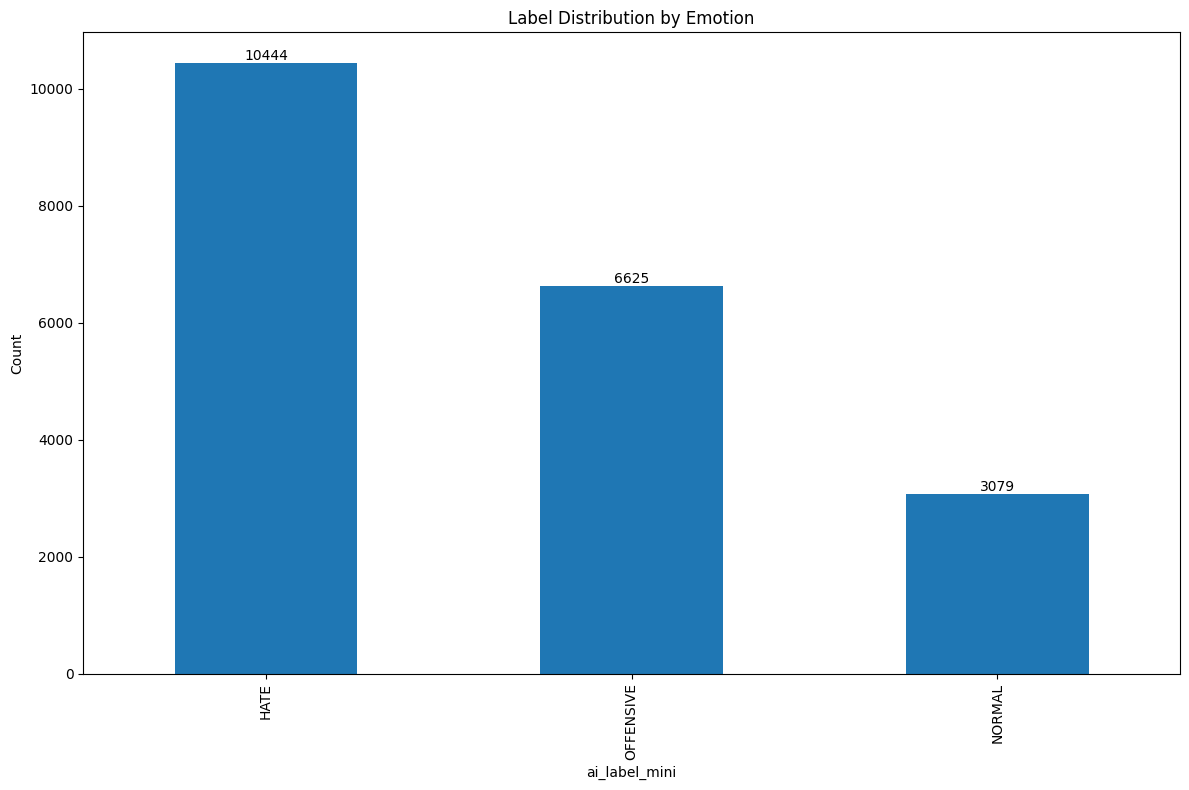

In [ ]:
# As shown by below plot, there are class-imbalance issues
# Therefore, we would need to balance the class distribution in the training set, we will do so by using a balanced class weights in training
plt.figure(figsize = (12,8))
status_counts = df_clean[LABEL_COLUMN].value_counts()
ax = status_counts.plot(kind = "bar")
for i, v in enumerate(status_counts):
    ax.text(i, v, str(v), ha = "center", va = "bottom")

plt.title("Label Distribution by Emotion")
plt.xlabel(LABEL_COLUMN)
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## 2.3 Master Data Split

### 2.3.1 Define groups for splitting

In [ ]:
groups = df_clean[TEXT_COLUMN]
y = df_clean[LABEL_COLUMN_ENCODED]

### 2.3.2. First split: train vs test

In [ ]:
gss_test = GroupShuffleSplit(
    n_splits = 1,
    test_size = 0.20,        # 20% test
    random_state = RANDOM_STATE,
)

train_idx, test_idx = next(gss_test.split(df_clean, y, groups = groups))

# Use a separate split array (positional) to avoid .loc / index confusion
split = np.array(["train"] * len(df_clean), dtype = object)
split[test_idx] = "test"
df_clean["split"] = split

print("After train/test split:")
print(df_clean["split"].value_counts())

After train/test split:
split
train    16122
test      4026
Name: count, dtype: int64


### 2.3.3. Second split: train -> train + val (within train only)

In [ ]:
train_mask = df_clean["split"] == "train"
train_pos_indices = np.where(train_mask)[0]      # positions in the full df
df_train_only = df_clean.loc[train_mask].copy().reset_index(drop = True)

groups_train = df_train_only[TEXT_COLUMN]
y_train = df_train_only[LABEL_COLUMN_ENCODED]

gss_val = GroupShuffleSplit(
    n_splits = 1,
    test_size = 0.25,        # 25% of *train* -> 0.25 * 0.8 = 0.20 of full data
    random_state = RANDOM_STATE,
)

train_idx2, val_idx = next(
    gss_val.split(df_train_only, y_train, groups = groups_train)
)

# Map positions within df_train_only back to global positions in df
train2_global = train_pos_indices[train_idx2]
val_global = train_pos_indices[val_idx]

# Update split array
split[:] = "train"
split[val_global] = "val"
split[test_idx] = "test"
df_clean["split"] = split

print("\nFinal split counts:")
print(df_clean["split"].value_counts())



Final split counts:
split
train    12096
test      4026
val       4026
Name: count, dtype: int64


### 2.3.4. Sanity checks

In [ ]:
# (a) No text group appears in more than one split
group_split_counts = df_clean.groupby(TEXT_COLUMN)["split"].nunique()
n_leaky_groups = (group_split_counts > 1).sum()
print("\nNumber of text groups that appear in >1 split:", n_leaky_groups)
assert n_leaky_groups == 0, "Some text groups leak across splits!"

# (b) Rough proportions
n_total = len(df_clean)
split_props = df_clean["split"].value_counts(normalize = True)
print("\nSplit proportions (approx):")
print(split_props)



Number of text groups that appear in >1 split: 0

Split proportions (approx):
split
train    0.600357
test     0.199821
val      0.199821
Name: proportion, dtype: float64


### 2.3.5. Save master split

In [ ]:
split_path = os.path.join(DRIVE_PROJECT_PATH, "hatexplain_master_split.csv")
df_clean.to_csv(split_path, index = False)
print("\nSaved master split to:", split_path)


Saved master split to: /content/drive/MyDrive/NLP_Projects/HateSpeech/4o_mini/hatexplain_master_split.csv


# 3. Classical ML Modeling

## 3.0 Pre-processing for classical ML Models


### Step 1: Copy clean data for classical ML models

In [ ]:
df_ml = df_clean.copy()

### Step 2: ML-specific preprocessing on ALL rows (train/val/test)

In [ ]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def ml_preprocess(text: str) -> str:
    if not isinstance(text, str):
        return ""
    # remove stopwords
    tokens = [w for w in text.split() if w not in stop_words]
    # lemmatize
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    return " ".join(tokens)

# Use a separate column for ML text so original df_clean['text'] is untouched
df_ml["text_ml"] = df_ml[TEXT_COLUMN].apply(ml_preprocess)

print("Example original vs ML-preprocessed text:")
print(df_ml[[TEXT_COLUMN, "text_ml"]].head())

Example original vs ML-preprocessed text:
                                                    text  \
1412                           the only kike here is you   
19482  it takes a certain kind of stupid to believe s...   
173    user user user user user follow the thread the...   
15403  this world is fast changing into a communist o...   
1275   like i am not an autumn faggot but i do want t...   

                                                 text_ml  
1412                                                kike  
19482  take certain kind stupid believe sjw logic say...  
173    user user user user user follow thread many pe...  
15403  world fast changing communist oligarchy time s...  
1275   like autumn faggot want go apple picking flex ...  


### Step 3: Build train/val/test splits for ML

In [ ]:
# Use the master split directly:
df_train_ml = df_ml[df_ml["split"] == "train"].copy()
df_val_ml = df_ml[df_ml["split"] == "val"].copy()
df_test_ml = df_ml[df_ml["split"] == "test"].copy()

print("ML split sizes:", len(df_train_ml), len(df_val_ml), len(df_test_ml))


# Texts and labels for ML (use cleaned master text)
X_train_ml = df_train_ml["text_ml"].tolist()
X_val_ml = df_val_ml["text_ml"].tolist()
X_test_ml = df_test_ml["text_ml"].tolist()

# Labels: pick whichever label column you’re modeling in this panel
y_train_ml = df_train_ml[LABEL_COLUMN].astype(str).values
y_val_ml = df_val_ml[LABEL_COLUMN].astype(str).values
y_test_ml = df_test_ml[LABEL_COLUMN].astype(str).values

ML split sizes: 12096 4026 4026


### Step 4: TF-IDF Vectorization

In [ ]:
tfidf = TfidfVectorizer(
    max_features = 10000,
    stop_words = "english"   # you can drop this, since you've already removed stopwords
)

# Fit on TRAIN ONLY
X_train_ml_tfidf = tfidf.fit_transform(X_train_ml)

# Transform val & test
X_val_ml_tfidf = tfidf.transform(X_val_ml)
X_test_ml_tfidf = tfidf.transform(X_test_ml)

print("TF-IDF shapes:",
      X_train_ml_tfidf.shape,
      X_val_ml_tfidf.shape,
      X_test_ml_tfidf.shape)

TF-IDF shapes: (12096, 10000) (4026, 10000) (4026, 10000)


### Step 5: Define Model Evaluation Functions for Classical Machine Learning Models


In [ ]:
# --- Helper Function 1: F1 Score Bootstrapping ---
def bootstrap_f1_ci(y_true, y_pred, n_iterations = 1000, average = "weighted"):
    """Calculates the F1 score and 95% CI using bootstrapping."""
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    f1_scores = []

    for _ in range(n_iterations):
        indices = resample(np.arange(len(y_true)))
        try:
            f1 = f1_score(y_true[indices], y_pred[indices], average = average)
            f1_scores.append(f1)
        except ValueError:
            continue  # Skip bootstrap sample if it's invalid

    if not f1_scores:
        return np.nan, np.nan, np.nan

    f1_mean = np.mean(f1_scores)
    ci_lower = np.percentile(f1_scores, 2.5)
    ci_upper = np.percentile(f1_scores, 97.5)
    return f1_mean, ci_lower, ci_upper


# --- Helper Function 2: Macro-AUC Bootstrapping ---
def bootstrap_auc_ci_multiclass(y_true, y_scores, n_iterations = 1000, average = "macro"):
    """Calculates the Macro-AUC and 95% CI using bootstrapping."""
    auc_scores = []
    y_true = np.array(y_true)
    y_scores = np.array(y_scores)

    for _ in range(n_iterations):
        indices = resample(np.arange(len(y_true)))

        y_true_sample = y_true[indices]
        y_scores_sample = y_scores[indices]

        try:
            auc_sample = roc_auc_score(
                y_true_sample,
                y_scores_sample,
                average = average,
                multi_class = "ovr"
            )
            auc_scores.append(auc_sample)
        except ValueError:
            continue  # Skip bootstrap sample if it's missing a class

    if not auc_scores:
        return np.nan, np.nan, np.nan

    return (
        np.mean(auc_scores),
        np.percentile(auc_scores, 2.5),
        np.percentile(auc_scores, 97.5),
    )


# --- Helper Function 3: Confusion Matrix Plot ---
def plot_confusion_matrix(
    y_true,
    y_pred,
    labels,
    model_name = "Model",
    save_dir = None,
    cmap_name = "Blues",
):
    """
    Plots a labeled confusion matrix and optionally saves it to disk.
    """
    conf_matrix = confusion_matrix(y_true, y_pred, labels = labels)

    plt.figure(figsize = (8, 6))
    sns.heatmap(
        conf_matrix,
        annot = True,
        fmt = "d",
        cmap = cmap_name,
        xticklabels = labels,
        yticklabels = labels,
        vmin = 0,
        vmax = conf_matrix.max(),
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.tight_layout()

    if save_dir is not None:
        os.makedirs(save_dir, exist_ok = True)
        cm_path = os.path.join(save_dir, f"{model_name}_confusion_matrix.png")
        plt.savefig(cm_path, dpi = 300)
        print(f"Saved confusion matrix to: {cm_path}")

    plt.show()


# --- Helper Function 4: Multi-class ROC Plot ---
def plot_multiclass_roc(
    y_true,
    y_score,
    classes_list,
    label_prefix = "Model",
    save_dir = None,
):
    """
    Plots a multi-class ROC curve (one-vs-rest) and optionally saves it.
    """
    y_true_bin = label_binarize(y_true, classes = classes_list)
    n_classes = len(classes_list)

    fpr = {}
    tpr = {}
    roc_auc = {}

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    colors = sns.color_palette("mako", n_classes)

    plt.figure(figsize = (10, 8))
    for i, (class_label, color) in enumerate(zip(classes_list, colors)):
        plt.plot(
            fpr[i],
            tpr[i],
            color = color,
            lw = 2,
            label = f"Class {class_label} (AUC = {roc_auc[i]:.2f})",
        )

    plt.plot([0, 1], [0, 1], "k--", lw = 2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{label_prefix} - Multi-class ROC Curve")
    plt.legend(loc = "lower right")
    plt.tight_layout()

    if save_dir is not None:
        os.makedirs(save_dir, exist_ok = True)
        roc_path = os.path.join(save_dir, f"{label_prefix}_roc_curve.png")
        plt.savefig(roc_path, dpi = 300)
        print(f"Saved ROC curve to: {roc_path}")

    plt.show()


# --- MAIN EVALUATION WRAPPER (for scikit-learn models) ---
def evaluate_ML_multiclass(model, X_test, y_test, model_name = "Model"):
    """
    Runs a full evaluation for a fitted scikit-learn classifier.
    Calculates metrics, CIs, and plots, and saves CM/ROC to DRIVE_PROJECT_PATH.
    """
    print(f"\n--- Evaluation Report: {model_name} ---\n")

    y_pred = model.predict(X_test)
    classes_list = model.classes_

    print("Classification Report:")
    print(classification_report(y_test, y_pred, digits = 4, labels = classes_list))

    f1_mean, f1_ci_low, f1_ci_high = bootstrap_f1_ci(
        y_test, y_pred, average = "weighted"
    )
    print(f"Weighted F1 Score: {f1_mean:.4f}")
    print(f"95% CI for F1 Score: [{f1_ci_low:.4f}, {f1_ci_high:.4f}]")

    plot_confusion_matrix(
        y_test,
        y_pred,
        labels = classes_list,
        model_name = model_name,
        save_dir = DRIVE_PROJECT_PATH,
        cmap_name = "Blues",
    )

    if hasattr(model, "predict_proba"):
        y_scores = model.predict_proba(X_test)
    elif hasattr(model, "decision_function"):
        y_scores = model.decision_function(X_test)
    else:
        print("Model doesn't support probability or decision scores.")
        return

    auc_score, auc_ci_low, auc_ci_high = bootstrap_auc_ci_multiclass(
        y_test, y_scores
    )
    print(f"\nMacro-Averaged AUC: {auc_score:.4f}")
    print(f"95% CI for Macro-Averaged AUC: [{auc_ci_low:.4f}, {auc_ci_high:.4f}]")

    plot_multiclass_roc(
        y_test,
        y_scores,
        classes_list,
        label_prefix = model_name,
        save_dir = DRIVE_PROJECT_PATH,
    )

## 3.1 Logistic Regression

### Step 1: Hyperparameter Tuning

In [ ]:
random.seed(2025)

# Parameter grid for logistic regression
param_grid = {
    "C": [0.1, 1, 10],                # Regularization strength
    "solver": ["lbfgs", "saga"],      # Optimization solvers
    "penalty": ["l2"],                # L2 regularization
    "multi_class": ["multinomial"],   # Multiclass strategy
    "class_weight": ["balanced", None],     # Handle class imbalance
}

# Initialize variables to track the best model and parameters
best_f1 = 0
best_model_lr = None
best_params_lr = None

# Start timer
start_time = time.time()
print("Starting manual Logistic Regression tuning...")

# Iterate through reduced parameter grid
for C, solver, penalty, multi_class, class_weight in product(
        param_grid["C"], param_grid["solver"], param_grid["penalty"], param_grid["multi_class"], param_grid["class_weight"]):
    try:
        # Set n_jobs for 'saga' solver (lbfgs doesn't support it)
        n_jobs = -1 if solver == "saga" else None

        # Create the Logistic Regression model
        model = LogisticRegression(
            C = C,
            solver = solver,
            penalty = penalty,
            multi_class = multi_class,
            class_weight = class_weight,
            max_iter = 1000,
            random_state = RANDOM_STATE,
            n_jobs = n_jobs
        )

        # Train the model
        model.fit(X_train_ml_tfidf, y_train_ml)

        # Validate the model on validation set
        y_val_pred = model.predict(X_val_ml_tfidf)
        f1 = f1_score(y_val_ml, y_val_pred, average = "weighted")

        # Update the best model if current one is better
        if f1 > best_f1:
            best_f1 = f1
            best_model_lr = model
            best_params_lr = {
                "C": C,
                "solver": solver,
                "penalty": penalty,
                "multi_class": multi_class,
                "class_weight": class_weight
            }
            print(f"New Best F1: {f1:.4f} with params: {best_params_lr}")

    except Exception as e:
        print(f"Skipping combination due to error: {e}")

# End timer
end_time = time.time()
total_time = end_time - start_time
print(f"Total Parameter Tuning Time: {total_time:.2f} seconds")

# Print the best parameters and F1 score on validation set
print("\nBest Hyperparameters:", best_params_lr)
print("Best Validation F1-Score:", best_f1)

Starting manual Logistic Regression tuning...
New Best F1: 0.6806 with params: {'C': 0.1, 'solver': 'lbfgs', 'penalty': 'l2', 'multi_class': 'multinomial', 'class_weight': 'balanced'}
New Best F1: 0.6811 with params: {'C': 0.1, 'solver': 'saga', 'penalty': 'l2', 'multi_class': 'multinomial', 'class_weight': 'balanced'}
New Best F1: 0.6993 with params: {'C': 1, 'solver': 'lbfgs', 'penalty': 'l2', 'multi_class': 'multinomial', 'class_weight': 'balanced'}
New Best F1: 0.7002 with params: {'C': 1, 'solver': 'saga', 'penalty': 'l2', 'multi_class': 'multinomial', 'class_weight': 'balanced'}
Total Parameter Tuning Time: 64.79 seconds

Best Hyperparameters: {'C': 1, 'solver': 'saga', 'penalty': 'l2', 'multi_class': 'multinomial', 'class_weight': 'balanced'}
Best Validation F1-Score: 0.7002176910255407


### Step 2: Model Construction

In [ ]:
# Create the SVM model with the best params
LR = LogisticRegression(
    **best_params_lr,
    max_iter = 1000,
    random_state = RANDOM_STATE
)

# Train the model
LR.fit(X_train_ml_tfidf, y_train_ml)

LogisticRegression(C=1, class_weight='balanced', max_iter=1000,
                   multi_class='multinomial', random_state=42, solver='saga')

### Step 3: Model Evaluation


--- Evaluation Report: Logistic Regression ---

Classification Report:
              precision    recall  f1-score   support

        HATE     0.8372    0.7500    0.7912      2036
      NORMAL     0.4335    0.6156    0.5087       614
   OFFENSIVE     0.6489    0.6272    0.6378      1376

    accuracy                         0.6875      4026
   macro avg     0.6398    0.6643    0.6459      4026
weighted avg     0.7112    0.6875    0.6957      4026

Weighted F1 Score: 0.6962
95% CI for F1 Score: [0.6816, 0.7106]
Saved confusion matrix to: /content/drive/MyDrive/NLP_Projects/HateSpeech/4o_mini/Logistic Regression_confusion_matrix.png


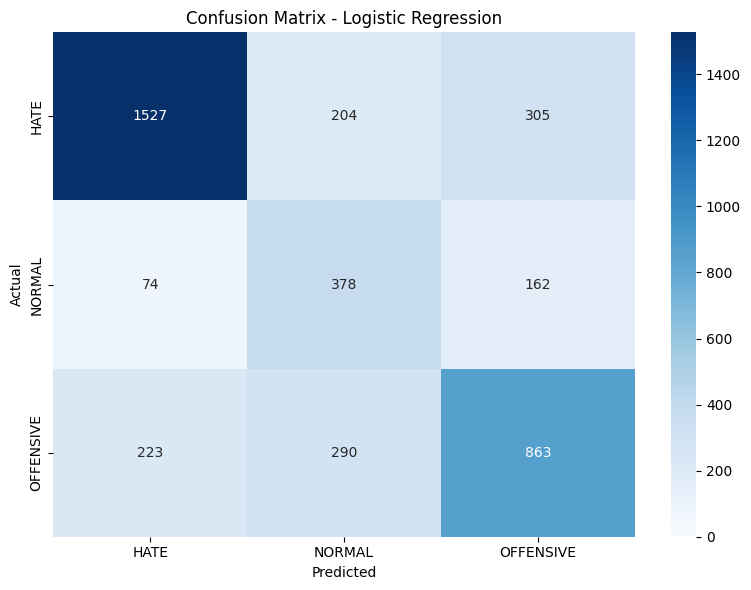


Macro-Averaged AUC: 0.8474
95% CI for Macro-Averaged AUC: [0.8375, 0.8570]
Saved ROC curve to: /content/drive/MyDrive/NLP_Projects/HateSpeech/4o_mini/Logistic Regression_roc_curve.png


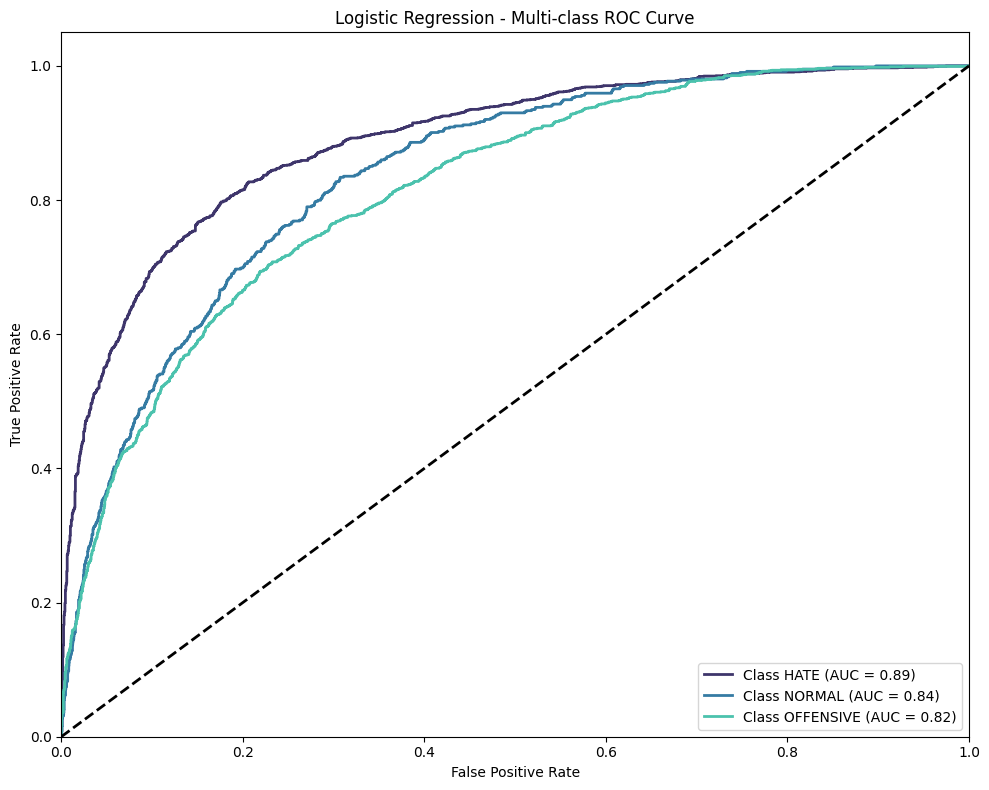

In [ ]:
evaluate_ML_multiclass(LR, X_test_ml_tfidf, y_test_ml, model_name = "Logistic Regression")


### Step 4: Model Interpretation

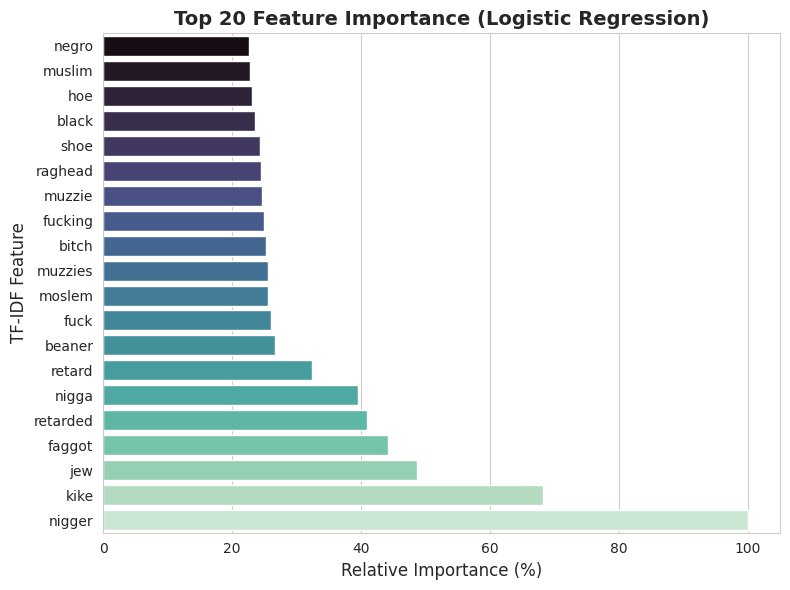

       Feature  Importance  Scaled Importance
6418    nigger    7.286295         100.000000
5050      kike    4.966364          68.160343
4691       jew    3.552337          48.753686
2855    faggot    3.222480          44.226588
7722  retarded    2.983129          40.941644
6414     nigga    2.880520          39.533394
7720    retard    2.355920          32.333581
679     beaner    1.944950          26.693266
3182      fuck    1.901249          26.093494
6178    moslem    1.865573          25.603857
6270   muzzies    1.864178          25.584719
803      bitch    1.845182          25.324011
3186   fucking    1.821213          24.995047
6269    muzzie    1.798185          24.679005
7427   raghead    1.780823          24.440718
8244      shoe    1.771457          24.312175
818      black    1.719064          23.593120
3742       hoe    1.683334          23.102739
6246    muslim    1.655613          22.722292
6349     negro    1.653964          22.699660


In [ ]:
# --- 1. Check if Model is Fitted ---
if LR is not None and hasattr(LR, "coef_"):

    # --- 2. Get Feature Names and Coefficients ---

    # Get the feature names (the words) from your fitted TF-IDF vectorizer
    feature_names = tfidf.get_feature_names_out()

    # --- CRITICAL IMPROVEMENT ---
    # Your model is 'multinomial', so LR.coef_ has shape (n_classes, n_features).
    # We must average the importance across all classes, not just take the first one.
    if LR.coef_.shape[0] > 1:
        # Average the *absolute* coefficient values across all 8 classes
        importances = np.abs(LR.coef_).mean(axis = 0)
    else:
        # Fallback for a binary/OVR model (takes absolute value of the one row)
        importances = np.abs(LR.coef_[0])

    # --- 3. Create and Process Importance DataFrame ---

    # Create a DataFrame to hold features and their calculated importances
    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    })

    # Normalize importance (rescale to 0–100)
    # This makes the chart easier to read as "Relative Importance (%)"
    importance_df["Scaled Importance"] = (
        importance_df["Importance"] / importance_df["Importance"].max()
    ) * 100

    # Sort by importance and get the top 20 features
    top_20_features = importance_df.sort_values(by = "Importance", ascending = False).head(20)

    # --- 4. Plot the Top 20 Features ---

    # Plot (horizontal bar chart)
    plt.figure(figsize = (8, 6))
    sns.set_style("whitegrid")
    sns.barplot(
        x = "Scaled Importance",
        y = "Feature",
        data = top_20_features[::-1],  # Reverse [::-1] to plot the most important feature at the top
        palette = "mako"
    )

    # Set titles and labels
    plt.title("Top 20 Feature Importance (Logistic Regression)", fontsize = 14, fontweight = "bold")
    plt.xlabel("Relative Importance (%)", fontsize = 12)
    plt.ylabel("TF-IDF Feature", fontsize = 12)
    plt.xticks(fontsize = 10)
    plt.yticks(fontsize = 10)
    plt.tight_layout()

    # Save a high-resolution version of the plot for your paper
    lr_imp_fig_path = os.path.join(DRIVE_PROJECT_PATH, "lr_token_importance_top20.png")
    plt.savefig(lr_imp_fig_path, dpi = 300)
    plt.show()

    # --- 5. Print the Top 20 (Optional) ---
    print(top_20_features[["Feature", "Importance", "Scaled Importance"]])

else:
    print("No LR model was trained successfully. Unable to display feature importance.")

## 3.2 Support Vector Machine

### Step 1: Hyperparameter Tuning

In [ ]:
random.seed(2025)

# Parameter grid
param_grid = {
    "C": [0.1, 1, 10],            # Regularization strength
    "kernel": ["linear", "rbf"],  # Commonly used kernels
    "class_weight": ["balanced", None], # Handle class imbalance
    "gamma": ["scale"],           # Default kernel coefficient, other options are available if needed
}

# Initialize variables to track the best model and parameters
best_f1 = 0
best_model_svc = None
best_params_svc = None

# Start timer
start_time = time.time()
print("Starting manual SVC tuning...")

# Iterate through reduced parameter grid
for C, kernel, class_weight, gamma in product(
        param_grid["C"], param_grid["kernel"], param_grid["class_weight"], param_grid["gamma"]):
    try:
        # Create the SVM model
        model = SVC(
            C = C,
            kernel = kernel,
            class_weight = class_weight,
            gamma = gamma,
            random_state = RANDOM_STATE,
            probability = True  # <-- CRITICAL: Required for AUC calculation
        )

        # Train the model
        model.fit(X_train_ml_tfidf, y_train_ml)

        # Validate the model on validation set
        y_val_pred = model.predict(X_val_ml_tfidf)
        f1 = f1_score(y_val_ml, y_val_pred, average = "weighted")

        # Update the best model if current one is better
        if f1 > best_f1:
            best_f1 = f1
            best_model_svc = model
            best_params_svc = {
                "C": C,
                "kernel": kernel,
                "class_weight": class_weight,
                "gamma": gamma
            }
            print(f"New Best F1: {f1:.4f} with params: {best_params_svc}")

    except Exception as e:
        print(f"Skipping combination due to error: {e}")

# End timer
end_time = time.time()
total_time = end_time - start_time
print(f"Total Parameter Tuning Time: {total_time:.2f} seconds")

# Print the best parameters and F1 score on validation set
print("\nBest Hyperparameters:", best_params_svc)
print("Best Validation F1-Score:", best_f1)

Starting manual SVC tuning...
New Best F1: 0.6463 with params: {'C': 0.1, 'kernel': 'linear', 'class_weight': 'balanced', 'gamma': 'scale'}
New Best F1: 0.6983 with params: {'C': 1, 'kernel': 'linear', 'class_weight': 'balanced', 'gamma': 'scale'}
New Best F1: 0.7004 with params: {'C': 1, 'kernel': 'linear', 'class_weight': None, 'gamma': 'scale'}
New Best F1: 0.7117 with params: {'C': 1, 'kernel': 'rbf', 'class_weight': 'balanced', 'gamma': 'scale'}
Total Parameter Tuning Time: 1411.37 seconds

Best Hyperparameters: {'C': 1, 'kernel': 'rbf', 'class_weight': 'balanced', 'gamma': 'scale'}
Best Validation F1-Score: 0.711735843556237


### Step 2: Model Construction

In [ ]:
# Create the SVM model with the best params
SVM = SVC(
    **best_params_svc,
    random_state = RANDOM_STATE,
    probability = True
)

# Train the model
SVM.fit(X_train_ml_tfidf, y_train_ml)

SVC(C=1, class_weight='balanced', probability=True, random_state=42)

### Step 3: Model Evaluation


--- Evaluation Report: SVM ---

Classification Report:
              precision    recall  f1-score   support

        HATE     0.8135    0.7947    0.8040      2036
      NORMAL     0.5090    0.4609    0.4838       614
   OFFENSIVE     0.6374    0.6860    0.6608      1376

    accuracy                         0.7067      4026
   macro avg     0.6533    0.6472    0.6495      4026
weighted avg     0.7069    0.7067    0.7062      4026

Weighted F1 Score: 0.7059
95% CI for F1 Score: [0.6916, 0.7197]
Saved confusion matrix to: /content/drive/MyDrive/NLP_Projects/HateSpeech/4o_mini/SVM_confusion_matrix.png


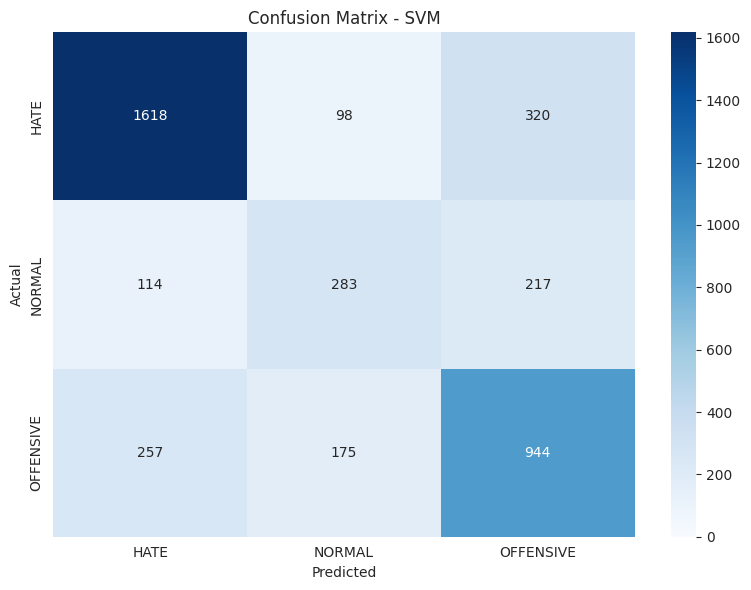


Macro-Averaged AUC: 0.8510
95% CI for Macro-Averaged AUC: [0.8412, 0.8608]
Saved ROC curve to: /content/drive/MyDrive/NLP_Projects/HateSpeech/4o_mini/SVM_roc_curve.png


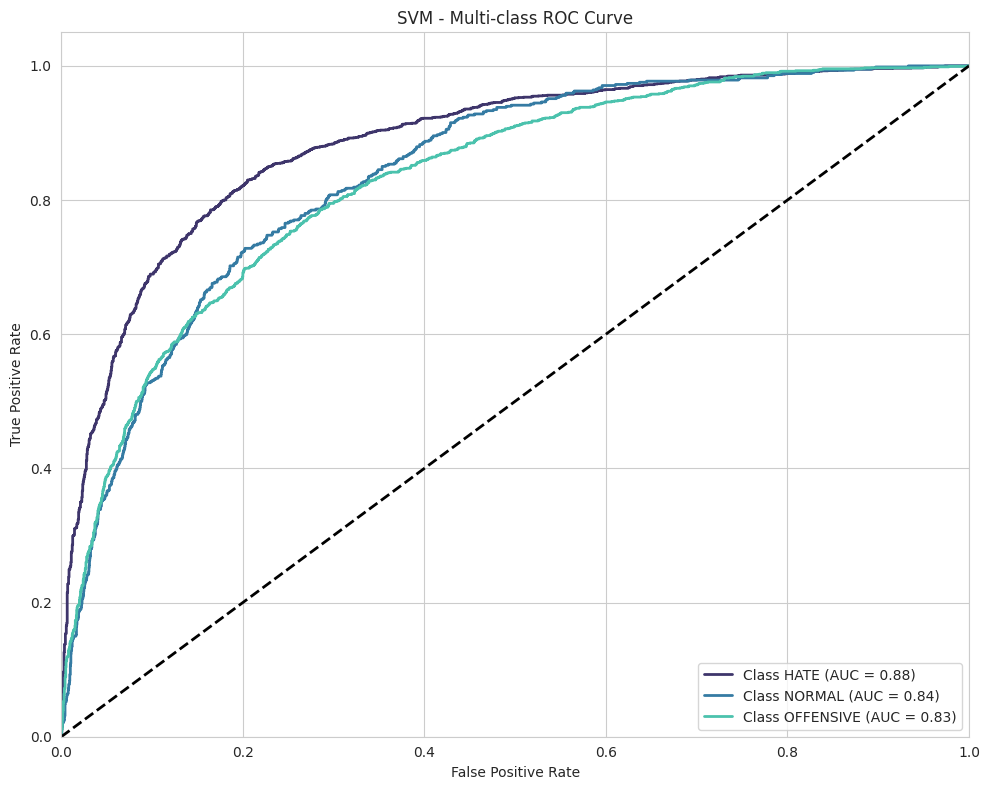

In [ ]:
evaluate_ML_multiclass(SVM, X_test_ml_tfidf, y_test_ml, model_name = "SVM")

### Step 4: Model Interpretation

Starting Permutation Importance calculation for SVM...
Using a subsample of the validation set for efficiency.
Permutation importance on 1000 samples, 10000 features.
Permutation importance finished in 10012.01 seconds.


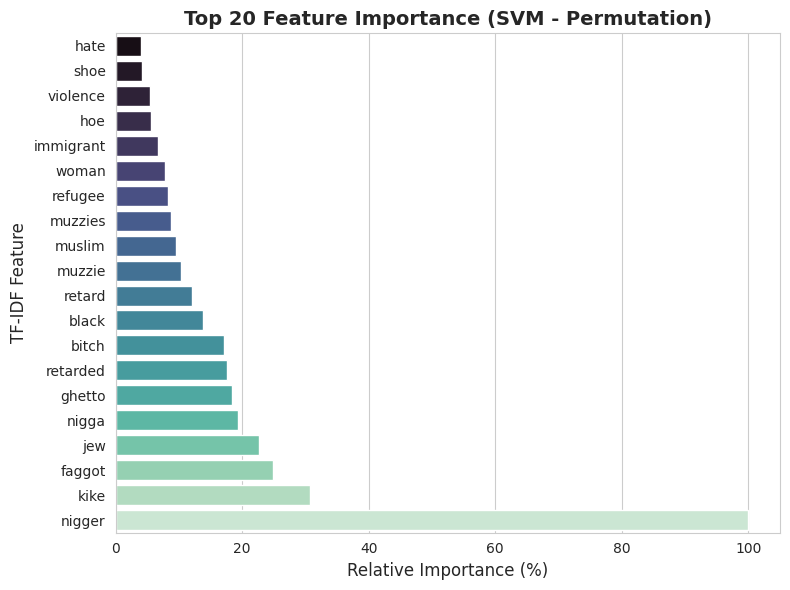

        Feature  Importance (Mean)  Scaled Importance
6418     nigger           0.077840         100.000000
5050       kike           0.023911          30.717377
2855     faggot           0.019363          24.875202
4691        jew           0.017657          22.683709
6414      nigga           0.015041          19.322624
3318     ghetto           0.014382          18.476487
7722   retarded           0.013756          17.671822
803       bitch           0.013396          17.209840
818       black           0.010771          13.836779
7720     retard           0.009368          12.035224
6269     muzzie           0.008088          10.390576
6246     muslim           0.007491           9.624065
6270    muzzies           0.006784           8.715151
7571    refugee           0.006444           8.278069
9838      woman           0.006109           7.847950
3975  immigrant           0.005208           6.691229
3742        hoe           0.004358           5.598271
9581   violence           0.

In [ ]:
# --- 1. Check if Model is Fitted ---
if SVM is not None and hasattr(SVM, "decision_function"):

    print("Starting Permutation Importance calculation for SVM...")
    print("Using a subsample of the validation set for efficiency.")

    # --- 2. Subsample validation set for permutation importance ---
    max_samples = 1000  # you can change the max_samples if needed
    n_val = X_val_ml_tfidf.shape[0]

    if n_val > max_samples:
        rng = np.random.RandomState(RANDOM_STATE)
        idx = rng.choice(n_val, size = max_samples, replace = False)
        X_perm_sparse = X_val_ml_tfidf[idx]
        y_perm = y_val_ml[idx]
    else:
        X_perm_sparse = X_val_ml_tfidf
        y_perm = y_val_ml

    # Convert to dense for permutation_importance
    X_perm = X_perm_sparse.toarray()

    print(f"Permutation importance on {X_perm.shape[0]} samples, "
          f"{X_perm.shape[1]} features.")

    # --- 3. Run Permutation Importance ---
    start_time = time.time()

    result = permutation_importance(
        SVM,
        X_perm,
        y_perm,
        n_repeats = 5,        # fewer repeats for speed
        random_state = RANDOM_STATE,
        n_jobs = -1,          # use all CPU cores
        scoring = "f1_weighted"
    )

    end_time = time.time()
    print(f"Permutation importance finished in {end_time - start_time:.2f} seconds.")

    # --- 4. Process the results ---
    feature_names = tfidf.get_feature_names_out()

    importance_df_svm = pd.DataFrame({
        "Feature": feature_names,
        "Importance (Mean)": result.importances_mean,
        "Importance (Std)": result.importances_std
    })

    # Clip small negatives to zero for readability
    importance_df_svm["Importance (Mean)"] = (
        importance_df_svm["Importance (Mean)"].clip(lower = 0)
    )

    # Scale to [0, 100] for relative importance
    max_mean = importance_df_svm["Importance (Mean)"].max()
    if max_mean > 0:
        importance_df_svm["Scaled Importance"] = (
            importance_df_svm["Importance (Mean)"] / max_mean * 100
        )
    else:
        importance_df_svm["Scaled Importance"] = 0.0

    # Top 20 features
    top_20_features_svm = (
        importance_df_svm
        .sort_values(by = "Importance (Mean)", ascending = False)
        .head(20)
    )

    # --- 5. Plot in grayscale ---
    plt.figure(figsize = (8, 6))
    sns.set_style("whitegrid")

    # Reverse order so most important is at top
    df_plot = top_20_features_svm.iloc[::-1]

    sns.barplot(
        x = "Scaled Importance",
        y = "Feature",
        data = df_plot,
        palette = "mako"
    )

    plt.title("Top 20 Feature Importance (SVM - Permutation)", fontsize = 14, fontweight = "bold")
    plt.xlabel("Relative Importance (%)", fontsize = 12)
    plt.ylabel("TF-IDF Feature", fontsize = 12)
    plt.xticks(fontsize = 10)
    plt.yticks(fontsize = 10)
    plt.tight_layout()

    svm_imp_fig_path = os.path.join(DRIVE_PROJECT_PATH, "svm_token_importance_top20.png")
    plt.savefig(svm_imp_fig_path, dpi = 300)
    plt.show()

    print(top_20_features_svm[["Feature", "Importance (Mean)", "Scaled Importance"]])

else:
    print("No SVM model was trained successfully, or model lacks decision_function. "
          "Unable to compute permutation-based feature importance.")

## 3.3 Random Forest

### Step 1: Hyperparameter Tuning

In [ ]:
random.seed(2025)

# Parameter grid for Random Forest
param_grid = {
    "n_estimators": [50, 100, 200],       # Number of trees
    "max_depth": [None, 10, 20],          # Depth of the tree
    "min_samples_split": [2, 5, 10],      # Minimum samples required to split a node
    "min_samples_leaf": [1, 2, 4],        # Minimum samples required at a leaf node
    "class_weight": ["balanced", None],   # Handle class imbalance
}

# Initialize variables to track the best model and parameters
best_f1 = 0
best_model_rf = None
best_params_rf = None

# Start timer
start_time = time.time()
print("Starting manual Random Forest tuning...")

# Iterate through reduced parameter grid
for n_estimators, max_depth, min_samples_split, min_samples_leaf, class_weight in product(
        param_grid["n_estimators"],
        param_grid["max_depth"],
        param_grid["min_samples_split"],
        param_grid["min_samples_leaf"],
        param_grid["class_weight"]):
    try:
        # Create the Random Forest model with current parameters
        model = RandomForestClassifier(
            n_estimators = n_estimators,
            max_depth = max_depth,
            min_samples_split = min_samples_split,
            min_samples_leaf = min_samples_leaf,
            class_weight = class_weight,
            random_state = RANDOM_STATE,
            n_jobs = -1  # <-- Add n_jobs = -1 to speed up individual model training
        )

        # Train the model on the training set
        model.fit(X_train_ml_tfidf, y_train_ml)

        # Validate the model on the (single) validation set
        y_val_pred = model.predict(X_val_ml_tfidf)
        f1 = f1_score(y_val_ml, y_val_pred, average = "weighted")

        # Update the best model if current one is better
        if f1 > best_f1:
            best_f1 = f1
            best_model_rf = model
            best_params_rf = {
                "n_estimators": n_estimators,
                "max_depth": max_depth,
                "min_samples_split": min_samples_split,
                "min_samples_leaf": min_samples_leaf,
                "class_weight": class_weight
            }
            print(f"New Best F1: {f1:.4f} with params: {best_params_rf}")

    except Exception as e:
        print(f"Skipping combination due to error: {e}")

# End timer
end_time = time.time()
total_time = end_time - start_time
print(f"Total Parameter Tuning Time: {total_time:.2f} seconds")

# Print the best parameters and F1 score on validation set
print("\nBest Hyperparameters:", best_params_rf)
print("Best Validation F1-Score:", best_f1)

Starting manual Random Forest tuning...
New Best F1: 0.7058 with params: {'n_estimators': 50, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1, 'class_weight': 'balanced'}
New Best F1: 0.7073 with params: {'n_estimators': 50, 'max_depth': None, 'min_samples_split': 5, 'min_samples_leaf': 1, 'class_weight': 'balanced'}
New Best F1: 0.7110 with params: {'n_estimators': 50, 'max_depth': None, 'min_samples_split': 10, 'min_samples_leaf': 1, 'class_weight': 'balanced'}
Total Parameter Tuning Time: 135.65 seconds

Best Hyperparameters: {'n_estimators': 50, 'max_depth': None, 'min_samples_split': 10, 'min_samples_leaf': 1, 'class_weight': 'balanced'}
Best Validation F1-Score: 0.7110048062209832


### Step 2: Model Construction

In [ ]:
# Create the Random Forest model with the best params
RandomForest = RandomForestClassifier(
    **best_params_rf,
    random_state = RANDOM_STATE
)

# Train the model
RandomForest.fit(X_train_ml_tfidf, y_train_ml)

RandomForestClassifier(class_weight='balanced', min_samples_split=10,
                       n_estimators=50, random_state=42)

### Step 3: Model Evaluation


--- Evaluation Report: RandomForest ---

Classification Report:
              precision    recall  f1-score   support

        HATE     0.8095    0.8266    0.8180      2036
      NORMAL     0.4751    0.4511    0.4628       614
   OFFENSIVE     0.6510    0.6453    0.6482      1376

    accuracy                         0.7074      4026
   macro avg     0.6452    0.6410    0.6430      4026
weighted avg     0.7044    0.7074    0.7058      4026

Weighted F1 Score: 0.7058
95% CI for F1 Score: [0.6910, 0.7192]
Saved confusion matrix to: /content/drive/MyDrive/NLP_Projects/HateSpeech/4o_mini/RandomForest_confusion_matrix.png


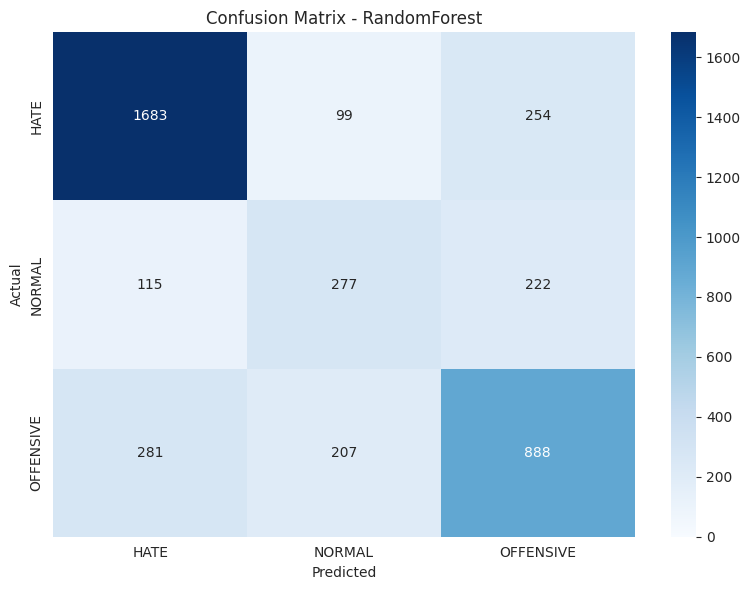


Macro-Averaged AUC: 0.8449
95% CI for Macro-Averaged AUC: [0.8342, 0.8551]
Saved ROC curve to: /content/drive/MyDrive/NLP_Projects/HateSpeech/4o_mini/RandomForest_roc_curve.png


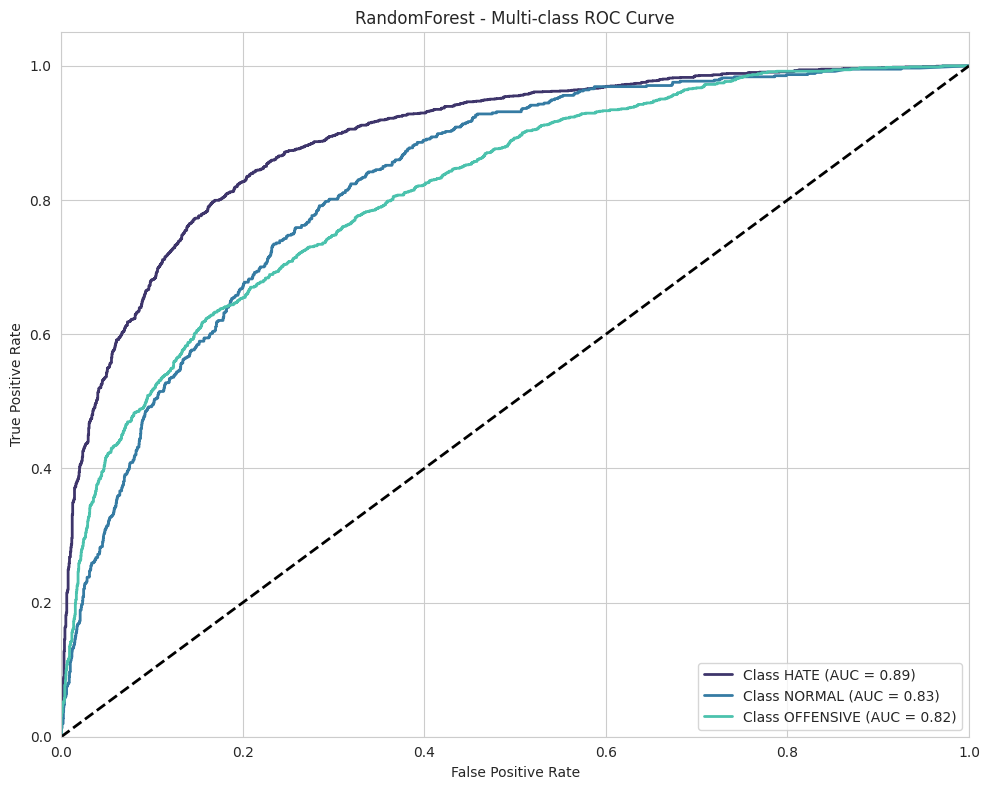

In [ ]:
evaluate_ML_multiclass(RandomForest, X_test_ml_tfidf, y_test_ml, model_name = "RandomForest")


### Step 4: Model Interpretation

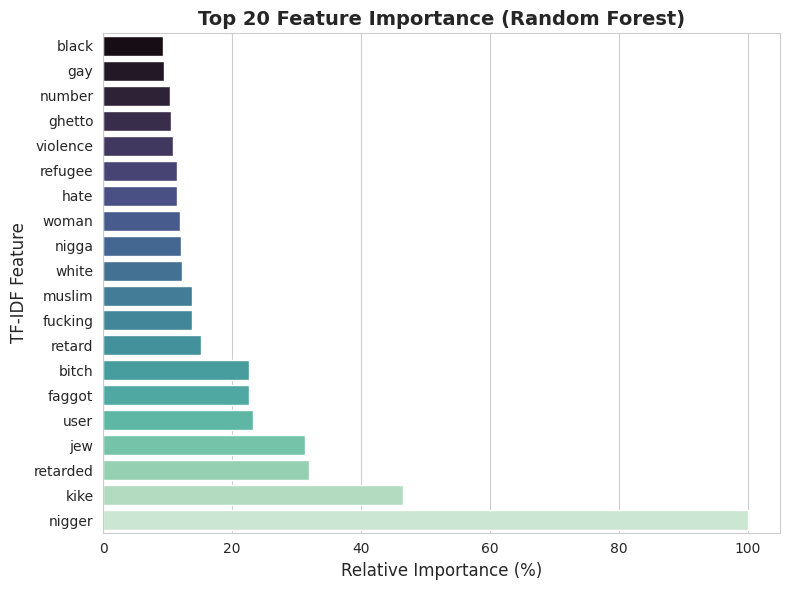

       Feature  Importance  Scaled Importance
6418    nigger    0.056706         100.000000
5050      kike    0.026400          46.555633
7722  retarded    0.018133          31.976584
4691       jew    0.017788          31.368639
9487      user    0.013220          23.313074
2855    faggot    0.012863          22.684557
803      bitch    0.012812          22.592916
7720    retard    0.008586          15.140709
3186   fucking    0.007852          13.846298
6246    muslim    0.007790          13.736691
9759     white    0.006924          12.210685
6414     nigga    0.006885          12.142034
9838     woman    0.006763          11.926136
3616      hate    0.006509          11.478646
7571   refugee    0.006471          11.410956
9581  violence    0.006126          10.803288
3318    ghetto    0.005933          10.463061
6500    number    0.005912          10.425812
3265       gay    0.005361           9.454838
818      black    0.005275           9.302726


In [ ]:
# --- 1. Check if Model is Fitted ---
if RandomForest is not None:

    # --- 2. Get Feature Names and Importances ---

    # Get the feature names (the words) from your fitted TF-IDF vectorizer
    feature_names = tfidf.get_feature_names_out()

    # Get the feature importances from the trained Random Forest model
    # (This is the mean decrease in impurity, or Gini importance)
    feature_importance = RandomForest.feature_importances_

    # --- 3. Create and Process Importance DataFrame ---

    # Create a DataFrame to hold features and their scores
    importance_df_rf = pd.DataFrame({
        "Feature": feature_names,
        "Importance": feature_importance
    })

    # Normalize importance (rescale to 0–100)
    importance_df_rf["Scaled Importance"] = (
        importance_df_rf["Importance"] / importance_df_rf["Importance"].max()
    ) * 100

    # Sort by importance and get the top 20 features
    top_20_features_rf = importance_df_rf.sort_values(by = "Importance", ascending = False).head(20)

    # --- 4. Plot the Top 20 Features ---

    plt.figure(figsize = (8, 6))
    sns.set_style("whitegrid")
    sns.barplot(
        x = "Scaled Importance",
        y = "Feature",
        data = top_20_features_rf[::-1],  # Reverse [::-1] to plot the most important feature at the top
        palette = "mako"
    )

    # Set titles and labels
    plt.title("Top 20 Feature Importance (Random Forest)", fontsize = 14, fontweight = "bold")
    plt.xlabel("Relative Importance (%)", fontsize = 12)
    plt.ylabel("TF-IDF Feature", fontsize = 12)
    plt.xticks(fontsize = 10)
    plt.yticks(fontsize = 10)
    plt.tight_layout()

    # Save a high-resolution version of the plot for your paper
    rf_imp_fig_path = os.path.join(DRIVE_PROJECT_PATH, "rf_token_importance_top20.png")
    plt.savefig(rf_imp_fig_path, dpi = 300)
    plt.show()

    # Optionally print the top 20
    print(top_20_features_rf[["Feature", "Importance", "Scaled Importance"]])

else:
    print("No model was trained successfully. Unable to display feature importance.")

## 3.4 LGBM

### Step 1: Hyperparameter Tuning

In [ ]:
import time
from itertools import product
from lightgbm import LGBMClassifier
from sklearn.metrics import f1_score

random.seed(1234)

# Parameter grid for LightGBM
param_grid = {
    "n_estimators": [100, 200],          # Number of boosting iterations
    "learning_rate": [0.01, 0.1, 0.2],       # Learning rate
    "num_leaves": [31, 63],              # Maximum number of leaves in a tree
    "max_depth": [None, 10],             # Maximum tree depth
    "class_weight": ["balanced", None],      # Handle class imbalance
}

# Initialize variables to track the best model and parameters
best_f1 = 0
best_model_lgbm = None
best_params_lgbm = None

# Start timer
start_time = time.time()
print("Starting manual LightGBM tuning...")

# Iterate through reduced parameter grid
for n_estimators, learning_rate, num_leaves, max_depth, class_weight in product(
        param_grid["n_estimators"],
        param_grid["learning_rate"],
        param_grid["num_leaves"],
        param_grid["max_depth"],
        param_grid["class_weight"]):
    try:
        # Create the LightGBM model with current parameters
        model = LGBMClassifier(
            objective = "multiclass",
            n_estimators = n_estimators,
            learning_rate = learning_rate,
            num_leaves = num_leaves,
            max_depth = max_depth,
            class_weight = class_weight,
            random_state = RANDOM_STATE,
            n_jobs = -1  # <-- Use all CPU cores
        )

        # Train the model
        model.fit(X_train_ml_tfidf, y_train_ml)

        # Validate the model on validation set
        y_val_pred = model.predict(X_val_ml_tfidf)
        f1 = f1_score(y_val_ml, y_val_pred, average = "weighted")

        # Update the best model if current one is better
        if f1 > best_f1:
            best_f1 = f1
            best_model_lgbm = model
            best_params_lgbm = {
                "n_estimators": n_estimators,
                "learning_rate": learning_rate,
                "num_leaves": num_leaves,
                "max_depth": max_depth,
                "class_weight": class_weight
            }
            print(f"New Best F1: {f1:.4f} with params: {best_params_lgbm}")

    except Exception as e:
        print(f"Skipping combination due to error: {e}")

# End timer
end_time = time.time()
total_time = end_time - start_time
print(f"Total Parameter Tuning Time: {total_time:.2f} seconds")

# Print the best parameters and F1 score on validation set
print("\nBest Hyperparameters:", best_params_lgbm)
print("Best Validation F1-Score:", best_f1)

Streaming output truncated to the last 5000 lines.
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

### Step 2: Model Construction

In [ ]:
# Create the LightGBM model with the best params
LGBM = LGBMClassifier(
    objective = "multiclass",
    **best_params_lgbm,
    random_state = RANDOM_STATE,
    importance_type = "gain",
    n_jobs = -1 # <-- Good to add this for speed
)

# Train the model
LGBM.fit(X_train_ml_tfidf, y_train_ml)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.022326 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 28032
[LightGBM] [Info] Number of data points in the train set: 12096, number of used features: 1120
[LightGBM] [Info] Start training from score -0.653119
[LightGBM] [Info] Start training from score -1.866402
[LightGBM] [Info] Start training from score -1.124235
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further 

LGBMClassifier(importance_type='gain', max_depth=10, n_estimators=200,
               n_jobs=-1, num_leaves=63, objective='multiclass',
               random_state=42)

### Step 3: Model Evaluation


--- Evaluation Report: LightGBM ---

Classification Report:
              precision    recall  f1-score   support

        HATE     0.8033    0.8345    0.8186      2036
      NORMAL     0.5057    0.3632    0.4227       614
   OFFENSIVE     0.6401    0.6839    0.6613      1376

    accuracy                         0.7111      4026
   macro avg     0.6497    0.6272    0.6342      4026
weighted avg     0.7021    0.7111    0.7045      4026

Weighted F1 Score: 0.7044
95% CI for F1 Score: [0.6902, 0.7201]
Saved confusion matrix to: /content/drive/MyDrive/NLP_Projects/HateSpeech/4o_mini/LightGBM_confusion_matrix.png


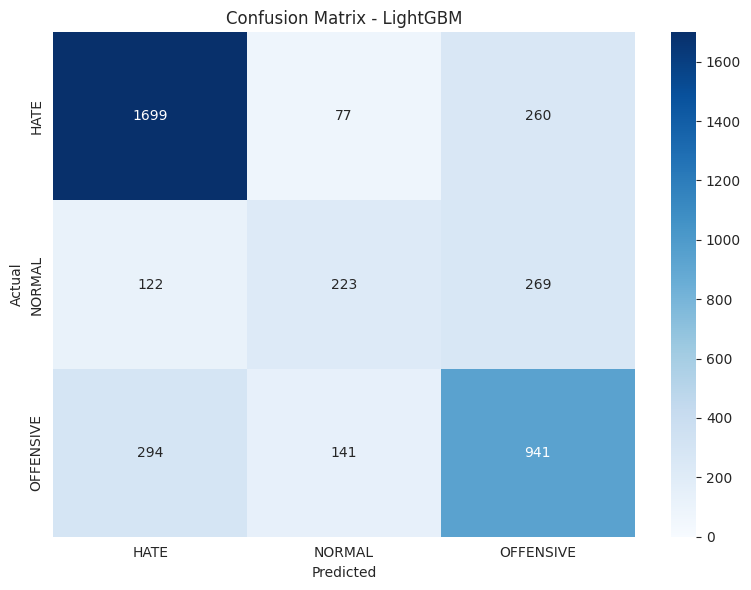


Macro-Averaged AUC: 0.8600
95% CI for Macro-Averaged AUC: [0.8505, 0.8691]
Saved ROC curve to: /content/drive/MyDrive/NLP_Projects/HateSpeech/4o_mini/LightGBM_roc_curve.png


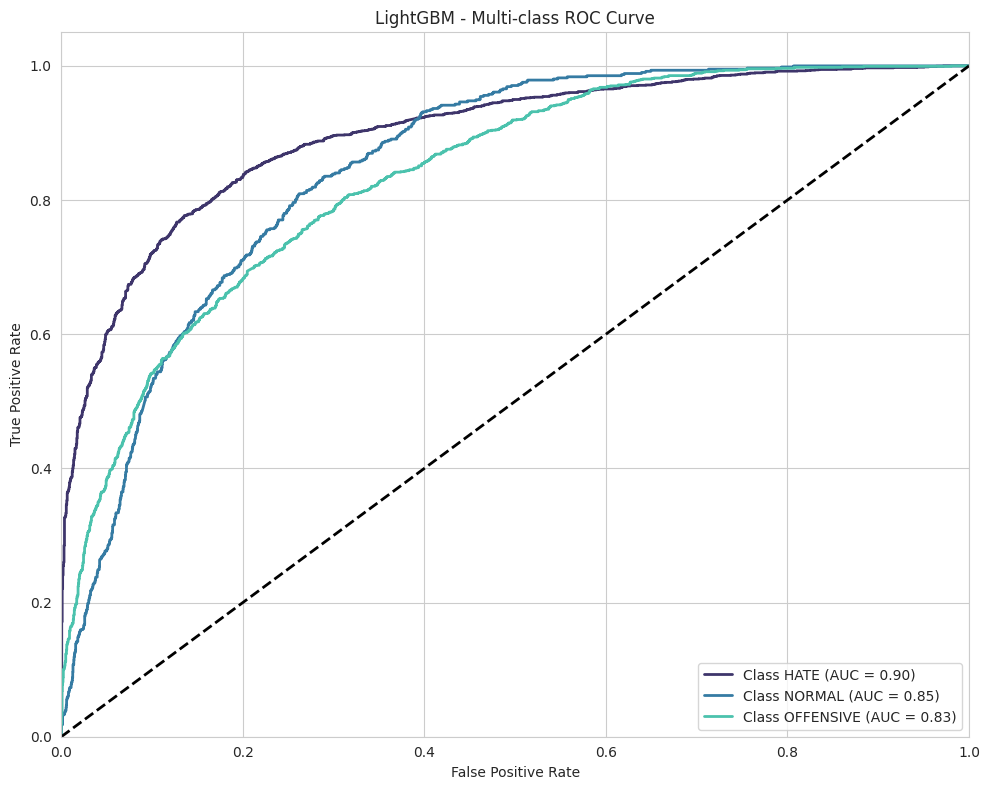

In [ ]:
evaluate_ML_multiclass(LGBM, X_test_ml_tfidf, y_test_ml, model_name = "LightGBM")


### Step 4: Model Interpretation

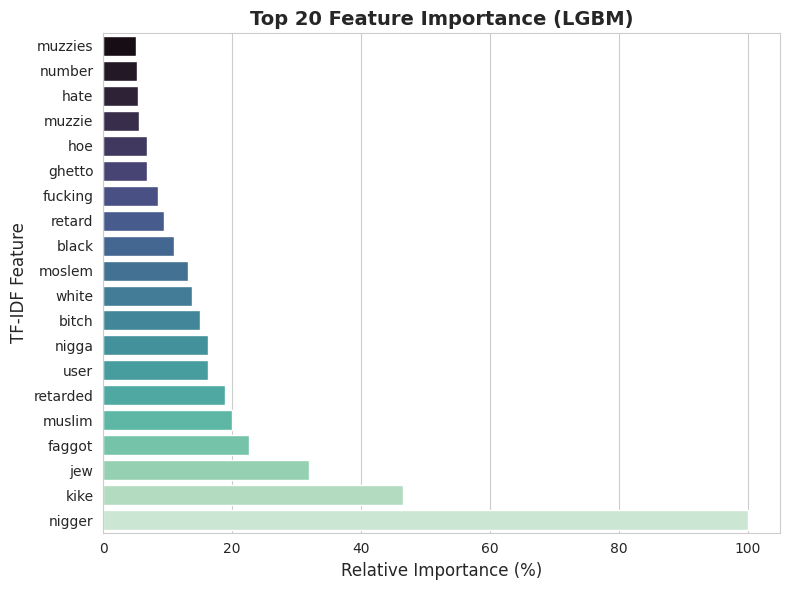

       Feature    Importance  Scaled Importance
6418    nigger  10091.606737         100.000000
5050      kike   4694.521227          46.519066
4691       jew   3214.767902          31.855858
2855    faggot   2282.425483          22.617067
6246    muslim   2014.196525          19.959126
7722  retarded   1901.479191          18.842185
9487      user   1643.541806          16.286225
6414     nigga   1634.159058          16.193250
803      bitch   1521.415484          15.076048
9759     white   1398.716238          13.860194
6178    moslem   1322.375863          13.103720
818      black   1107.547581          10.974938
7720    retard    949.950154           9.413270
3186   fucking    850.829958           8.431065
3318    ghetto    689.462140           6.832035
3742       hoe    681.216143           6.750324
6269    muzzie    564.778967           5.596522
3616      hate    552.751578           5.477340
6500    number    524.195609           5.194372
6270   muzzies    521.661771           5

In [ ]:
# --- 1. Check if Model is Fitted ---
if LGBM is not None:

    # --- 2. Get Feature Names and Importances ---

    # Get the feature names (the words) from your fitted TF-IDF vectorizer
    feature_names = tfidf.get_feature_names_out()

    # Get the feature importances from the trained LGBM model
    # (For LGBM, this typically represents "gain" or "split" count)
    feature_importance = LGBM.feature_importances_

    # --- 3. Create and Process Importance DataFrame ---

    # Create a DataFrame to hold features and their scores
    importance_df_lgbm = pd.DataFrame({
        "Feature": feature_names,
        "Importance": feature_importance
    })

    # Normalize importance (rescale to 0–100)
    importance_df_lgbm["Scaled Importance"] = (
        importance_df_lgbm["Importance"] / importance_df_lgbm["Importance"].max()
    ) * 100

    # Sort by importance and get the top 20 features
    top_20_features_lgbm = importance_df_lgbm.sort_values(by = "Importance", ascending = False).head(20)

    # --- 4. Plot the Top 20 Features ---

    plt.figure(figsize = (8, 6))
    sns.set_style("whitegrid")
    sns.barplot(
        x = "Scaled Importance",
        y = "Feature",
        data = top_20_features_lgbm[::-1],  # Reverse [::-1] to plot the most important feature at the top
        palette = "mako"
    )

    # Set titles and labels
    plt.title("Top 20 Feature Importance (LGBM)", fontsize = 14, fontweight = "bold")
    plt.xlabel("Relative Importance (%)", fontsize = 12)
    plt.ylabel("TF-IDF Feature", fontsize = 12)
    plt.xticks(fontsize = 10)
    plt.yticks(fontsize = 10)
    plt.tight_layout()

    # Save a high-resolution version of the plot for your paper
    lgbm_imp_fig_path = os.path.join(DRIVE_PROJECT_PATH, "lgbm_token_importance_top20.png")
    plt.savefig(lgbm_imp_fig_path, dpi = 300)
    plt.show()

    # Optionally print the top 20
    print(top_20_features_lgbm[["Feature", "Importance", "Scaled Importance"]])

else:
    print("No model was trained successfully. Unable to display feature importance.")

## 3.5 Save Predictions for Machine Learning Models

In [ ]:
# df_ml = df_clean.copy() with df_ml["text_ml"] already created
df_test_ml = df_ml[df_ml["split"] == "test"].copy()

# Sanity check: TF–IDF test features
assert X_test_ml_tfidf.shape[0] == len(df_test_ml)

# True labels (strings + encoded)
y_true_str = df_test_ml[LABEL_COLUMN].astype(str).values
y_true_id  = label_encoder.transform(y_true_str)

X_test_vec = X_test_ml_tfidf

# Predictions
lr_pred_str = LR.predict(X_test_vec)
lr_pred_proba = LR.predict_proba(X_test_vec)
svm_pred_str = SVM.predict(X_test_vec)
svm_pred_proba = SVM.predict_proba(X_test_vec)
rf_pred_str = RandomForest.predict(X_test_vec)
rf_pred_proba = RandomForest.predict_proba(X_test_vec)
lgbm_pred_str = LGBM.predict(X_test_vec)
lgbm_pred_proba = LGBM.predict_proba(X_test_vec)

# Ensure consistent class order
class_names = LR.classes_
assert np.array_equal(class_names, SVM.classes_)
assert np.array_equal(class_names, RandomForest.classes_)
assert np.array_equal(class_names, LGBM.classes_)

# ---------- KEY PART: construct id safely ----------
if "id" in df_test_ml.columns:
    # Use existing id column
    df_pred_ml = df_test_ml[["id", TEXT_COLUMN, "text_ml"]].copy()
else:
    # Fall back to index as id, and keep original text column
    df_pred_ml = df_test_ml[[TEXT_COLUMN, "text_ml"]].copy()
    df_pred_ml.insert(0, "id", df_test_ml.index)

df_pred_ml = df_pred_ml.rename(columns = {TEXT_COLUMN: "text_orig"})

# Labels + predictions
df_pred_ml["true_label"] = y_true_str
df_pred_ml["true_label_id"] = y_true_id

df_pred_ml["lr_pred"] = lr_pred_str
df_pred_ml["svm_pred"] = svm_pred_str
df_pred_ml["rf_pred"] = rf_pred_str
df_pred_ml["lgbm_pred"] = lgbm_pred_str

# Probabilities
for i, cls in enumerate(class_names):
    df_pred_ml[f"lr_prob_{cls}"] = lr_pred_proba[:, i]
    df_pred_ml[f"svm_prob_{cls}"] = svm_pred_proba[:, i]
    df_pred_ml[f"rf_prob_{cls}"] = rf_pred_proba[:, i]
    df_pred_ml[f"lgbm_prob_{cls}"] = lgbm_pred_proba[:, i]

df_pred_ml["split"] = "test"

save_path = os.path.join(DRIVE_PROJECT_PATH, "ml_models_predictions.csv")
df_pred_ml.to_csv(save_path, index=False)
print(f"Saved ML predictions to: {save_path}")

Saved ML predictions to: /content/drive/MyDrive/NLP_Projects/HateSpeech/4o_mini/ml_models_predictions.csv


# 4. DL Models


## 4.0 General Function for ALBERT \& GRU Models

### Define Model Evaluation Functions for GRU, CNN \& ALBERT models

In [ ]:
# --- Helper Function 1: F1 Score Bootstrapping ---
def bootstrap_f1_ci(y_true, y_pred, n_iterations = 1000, average = "weighted"):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    f1_scores = []

    for _ in range(n_iterations):
        indices = resample(np.arange(len(y_true)))
        try:
            f1 = f1_score(y_true[indices], y_pred[indices], average = average)
            f1_scores.append(f1)
        except ValueError:
            continue  # Skip bootstrap sample if it is invalid

    if not f1_scores:
        return np.nan, np.nan, np.nan

    f1_mean = np.mean(f1_scores)
    ci_lower = np.percentile(f1_scores, 2.5)
    ci_upper = np.percentile(f1_scores, 97.5)
    return f1_mean, ci_lower, ci_upper


# --- Helper Function 2: Macro-AUC Bootstrapping ---
# This version correctly takes 1D y_true and 2D y_scores
def bootstrap_auc_ci_multiclass(y_true, y_scores, n_iterations = 1000, average = "macro"):
    auc_scores = []
    y_true = np.array(y_true)
    y_scores = np.array(y_scores)

    for _ in range(n_iterations):
        indices = resample(np.arange(len(y_true)))
        y_true_sample = y_true[indices]
        y_scores_sample = y_scores[indices]

        try:
            # Pass the 1D y_true_sample to roc_auc_score
            auc_sample = roc_auc_score(
                y_true_sample,
                y_scores_sample,
                average = average,
                multi_class = "ovr"
            )
            auc_scores.append(auc_sample)
        except ValueError:
            continue  # Skip bootstrap sample if it is missing a class

    if not auc_scores:
        return np.nan, np.nan, np.nan

    return (
        np.mean(auc_scores),
        np.percentile(auc_scores, 2.5),
        np.percentile(auc_scores, 97.5),
    )


# --- Helper Function 3: Confusion Matrix Plot ---
# This version requires the "labels" (class names) list to be passed
def plot_confusion_matrix(
    y_true,
    y_pred,
    labels,
    model_name = None,
    save_dir = None,
):
    conf_matrix = confusion_matrix(y_true, y_pred)
    plt.figure(figsize = (8, 6))  # Adjusted size for 3 classes
    sns.heatmap(
        conf_matrix,
        annot = True,
        fmt = "d",
        cmap = "Blues",
        xticklabels = labels,
        yticklabels = labels,
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.tight_layout()

    if save_dir is not None and model_name is not None:
        filename = f"{model_name}_confusion_matrix.png"
        save_path = os.path.join(save_dir, filename)
        plt.savefig(save_path, dpi = 300)
        print(f"Saved confusion matrix to: {save_path}")

    plt.show()


# --- Helper Function 4: Multi-class ROC Plot ---
# This version correctly takes the "classes_list" (class names) for binarizing
def plot_multiclass_roc(
    y_true,
    y_score,
    classes_list,
    label_prefix = "Model",
    save_dir = None,
):
    # Binarize using the *actual* list of classes (assumed numeric 0..K-1)
    y_true_bin = label_binarize(y_true, classes = np.arange(len(classes_list)))
    n_classes = len(classes_list)

    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Automatically get n_classes of distinct colors from a colormap
    colors = sns.color_palette("mako", n_classes)

    plt.figure(figsize = (10, 8))

    # Loop over the class names for the plot label
    for i, (class_label, color) in enumerate(zip(classes_list, colors)):
        plt.plot(
            fpr[i],
            tpr[i],
            color = color,
            lw = 2,
            label = f"Class {class_label} (AUC = {roc_auc[i]:.2f})",
        )

    plt.plot([0, 1], [0, 1], "k--", lw = 2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{label_prefix} - Multi-class ROC Curve")
    plt.legend(loc = "lower right")
    plt.tight_layout()

    if save_dir is not None and label_prefix is not None:
        filename = f"{label_prefix}_roc_curve.png"
        save_path = os.path.join(save_dir, filename)
        plt.savefig(save_path, dpi = 300)
        print(f"Saved ROC curve to: {save_path}")

    plt.show()


# --- MAIN EVALUATION WRAPPER (for PyTorch models) ---
def evaluate_pytorch_multiclass(
    model,
    test_loader,
    device,
    label_encoder,
    model_name,
    use_attention_mask = True,
):
    """
    Runs a full evaluation for a fitted PyTorch classifier.
    Handles models with or without an attention mask.
    """

    model.eval()
    model.to(device)

    all_preds = []
    all_probs = []
    all_labels = []

    # Run the evaluation loop
    with torch.no_grad():
        for batch in tqdm(test_loader, desc = f"Evaluating {model_name}"):
            input_ids = batch["input_ids"].to(device)
            labels = batch["label"].to(device)

            # Use the attention mask only if the model needs it
            if use_attention_mask:
                attention_mask = batch["attention_mask"].to(device)
                outputs = model(input_ids = input_ids, attention_mask = attention_mask)
            else:
                outputs = model(input_ids = input_ids)  # For the GRU / CNN

            # Handle both tensor output and HF 'logits' output
            logits = outputs.logits if hasattr(outputs, "logits") else outputs

            # Save probabilities for ALL classes
            probs = torch.softmax(logits, dim = 1)
            # Get the final prediction
            preds = torch.argmax(probs, dim = 1)

            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    # Get the actual string names of your classes (e.g., "normal", "offensive", "hatespeech")
    classes_list = label_encoder.classes_

    print(f"\n--- Evaluation Report: {model_name} ---\n")

    # 1. Classification Report
    print("Classification Report:")
    print(
        classification_report(
            all_labels,
            all_preds,
            target_names = classes_list,
            digits = 4,
        )
    )

    # 2. F1 Score with CI
    f1_mean, f1_ci_low, f1_ci_high = bootstrap_f1_ci(
        all_labels,
        all_preds,
        average = "weighted",
    )
    print(f"Weighted F1 Score: {f1_mean:.4f}")
    print(f"95% CI for F1 Score: [{f1_ci_low:.4f}, {f1_ci_high:.4f}]")

    # 3. Confusion Matrix (now saved)
    plot_confusion_matrix(
        all_labels,
        all_preds,
        labels = classes_list,
        model_name = model_name,
        save_dir = DRIVE_PROJECT_PATH,  # <- use your configured drive path
    )

    # 4. Macro-Averaged AUC with CI
    auc_score, auc_ci_low, auc_ci_high = bootstrap_auc_ci_multiclass(
        all_labels,
        all_probs,
    )
    print(f"\nMacro-Averaged AUC: {auc_score:.4f}")
    print(f"95% CI for Macro-Averaged AUC: [{auc_ci_low:.4f}, {auc_ci_high:.4f}]")

    # 5. Per-Class ROC Curve Plot (now saved)
    plot_multiclass_roc(
        all_labels,
        all_probs,
        classes_list,
        label_prefix = model_name,
        save_dir = DRIVE_PROJECT_PATH,  # <- use your configured drive path
    )

## 4.1 GRU

### 4.1.1 Data Preprocessing

#### Step 1: Copy data for GRU modeling

In [ ]:
df_gru = df_clean.copy()

#### Step 2: Build train/val/test splits for GRU

In [ ]:
# Use the master split directly
df_train_gru = df_gru[df_gru["split"] == "train"].copy()
df_val_gru   = df_gru[df_gru["split"] == "val"].copy()
df_test_gru  = df_gru[df_gru["split"] == "test"].copy()

print("GRU split sizes:",
      len(df_train_gru), len(df_val_gru), len(df_test_gru))

# Texts and labels for GRU (use cleaned master text)
train_texts_gru = df_train_gru[TEXT_COLUMN].tolist()
val_texts_gru = df_val_gru[TEXT_COLUMN].tolist()
test_texts_gru = df_test_gru[TEXT_COLUMN].tolist()

# Labels: pick whichever label column you’re modeling in this panel
train_labels_gru = df_train_gru[LABEL_COLUMN_ENCODED].tolist()
val_labels_gru = df_val_gru[LABEL_COLUMN_ENCODED].tolist()
test_labels_gru = df_test_gru[LABEL_COLUMN_ENCODED].tolist()

GRU split sizes: 12096 4026 4026


#### Step 3: Prepare the data for GRU model

In [ ]:
# Build Vocabulary on Training Data Only
all_train_words = " ".join(train_texts_gru).split()
most_common_words = [word for word, _ in Counter(all_train_words).most_common(VOCAB_SIZE - 1)]
word_to_index = {word: idx + 1 for idx, word in enumerate(most_common_words)}

# Text-to-Sequence Conversion
def text_to_sequence(text, word_to_index, max_len = MAX_TOKEN_LENGTH):
    tokens = text.split()
    sequence = [word_to_index.get(word, 0) for word in tokens]
    return sequence[:max_len]

# Convert text to sequences for train, validation, and test sets
train_sequences_gru = [text_to_sequence(text, word_to_index) for text in train_texts_gru]
val_sequences_gru = [text_to_sequence(text, word_to_index) for text in val_texts_gru]
test_sequences_gru = [text_to_sequence(text, word_to_index) for text in test_texts_gru]

# Pad Sequences
train_sequences_gru = nn.utils.rnn.pad_sequence([torch.tensor(seq) for seq in train_sequences_gru], batch_first = True, padding_value = 0)
val_sequences_gru = nn.utils.rnn.pad_sequence([torch.tensor(seq) for seq in val_sequences_gru], batch_first = True, padding_value = 0)
test_sequences_gru = nn.utils.rnn.pad_sequence([torch.tensor(seq) for seq in test_sequences_gru], batch_first = True, padding_value = 0)

# Convert Labels
train_labels_gru = torch.tensor(train_labels_gru, dtype = torch.long)
val_labels_gru = torch.tensor(val_labels_gru, dtype = torch.long)
test_labels_gru = torch.tensor(test_labels_gru, dtype = torch.long)

# Dataset Class
class SentimentDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = texts
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids": self.texts[idx],
            "label": self.labels[idx]
        }

# Create Datasets and DataLoaders
train_dataset_gru = SentimentDataset(train_sequences_gru, train_labels_gru)
val_dataset_gru = SentimentDataset(val_sequences_gru, val_labels_gru)
test_dataset_gru = SentimentDataset(test_sequences_gru, test_labels_gru)

train_loader_gru = DataLoader(train_dataset_gru, batch_size = BATCH_SIZE, shuffle = True)
val_loader_gru = DataLoader(val_dataset_gru, batch_size = BATCH_SIZE)
test_loader_gru = DataLoader(test_dataset_gru, batch_size = BATCH_SIZE)

### 4.1.2 GRU Modeling

#### Step 1: Define GRU Model

In [ ]:
class GRUSentimentModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim):
        super(GRUSentimentModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.gru = nn.GRU(embedding_dim, hidden_dim, batch_first = True)
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(0.3)

    def forward(self, input_ids):
        embedded = self.embedding(input_ids)
        _, hidden = self.gru(embedded)  # Only last hidden state
        output = self.fc(self.dropout(hidden[-1]))
        return output

#### Step 2: Hyperparameter Tuning

In [ ]:
SEED = 2025
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

MAX_EPOCHS = 20
PATIENCE = 5

# Compute class weights once on train labels
train_labels_np = train_labels_gru.numpy()
class_weights = compute_class_weight(
    class_weight = "balanced",
    classes = np.unique(train_labels_np),
    y=train_labels_np
)
class_weights_tensor = torch.tensor(class_weights, dtype = torch.float32).to(device)

def train_and_evaluate(hyperparams, train_loader, val_loader, vocab_size, output_dim,
                       device, class_weights_tensor, max_epochs = 20, patience = 5):

    embedding_dim = int(hyperparams["embedding_dim"])
    hidden_dim = int(hyperparams["hidden_dim"])
    lr = hyperparams["lr"]

    model = GRUSentimentModel(vocab_size, embedding_dim, hidden_dim, output_dim).to(device)

    criterion = nn.CrossEntropyLoss(weight = class_weights_tensor)
    optimizer = torch.optim.Adam(model.parameters(), lr = lr)

    best_val_f1 = -1.0
    best_val_acc = 0.0
    best_state_dict = None
    epochs_no_improve = 0

    for epoch in range(max_epochs):
        # ---- TRAIN ----
        model.train()
        total_loss = 0.0

        for batch in train_loader:
            input_ids = batch["input_ids"].to(device)
            labels = batch["label"].to(device)

            optimizer.zero_grad()
            outputs = model(input_ids)
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm = 5.0)
            optimizer.step()

            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)

        # ---- VALIDATE ----
        model.eval()
        val_preds, val_true = [], []
        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch["input_ids"].to(device)
                labels = batch["label"].to(device)

                outputs = model(input_ids)
                preds = torch.argmax(outputs, dim = 1)

                val_preds.extend(preds.cpu().numpy())
                val_true.extend(labels.cpu().numpy())

        val_f1 = f1_score(val_true, val_preds, average = "weighted")
        val_acc = accuracy_score(val_true, val_preds)

        print(
            f"Epoch {epoch+1}/{max_epochs} | "
            f"Train Loss: {avg_train_loss:.4f} | "
            f"Val F1: {val_f1:.4f} | Val Acc: {val_acc:.4f}"
        )

        # ---- EARLY STOPPING ----
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_val_acc = val_acc
            best_state_dict = model.state_dict()
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"No improvement for {patience} epochs. Early stopping at epoch {epoch+1}.")
                break

    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)

    return best_val_f1, best_val_acc, model


def random_hyperparameter_tuning(train_loader, val_loader, vocab_size, output_dim,
                                 device, class_weights_tensor, n_iter = N_ITERATIONS):

    param_space = {
        "embedding_dim": (150, 300),
        "hidden_dim": (128, 384),
        "lr": (np.log10(1e-4), np.log10(1e-3)),  # log-uniform
    }

    best_f1 = -1.0
    best_params = None
    best_model = None

    with tqdm(total = n_iter, desc = "Random Search (GRU)", leave = True) as pbar:
        for _ in range(n_iter):
            hyperparams = {
                "embedding_dim": np.random.uniform(*param_space["embedding_dim"]),
                "hidden_dim":   np.random.uniform(*param_space["hidden_dim"]),
                "lr":           10 ** np.random.uniform(*param_space["lr"]),
            }

            f1_val, acc_val, model = train_and_evaluate(
                hyperparams, train_loader, val_loader, vocab_size, output_dim,
                device, class_weights_tensor, max_epochs = MAX_EPOCHS, patience = PATIENCE
            )

            pbar.set_postfix(f1 = f1_val, acc = acc_val)
            pbar.update(1)

            if f1_val > best_f1:
                best_f1 = f1_val
                best_params = hyperparams
                best_model = model

    print(f"\nBest Validation F1 (GRU): {best_f1:.4f}")
    print(f"Best Hyperparameters: {best_params}")

    # Save best model + params
    torch.save(best_model.state_dict(), BEST_GRU_PATH)
    with open(BEST_GRU_PARAMS_PATH, "w") as f:
        json.dump(best_params, f)

    return best_params, best_f1, best_model


# =========================
# 4. Run tuning
# =========================
start_time = time.time()

best_params_gru, best_f1_gru, best_model_gru = random_hyperparameter_tuning(
    train_loader = train_loader_gru, val_loader = val_loader_gru, vocab_size = VOCAB_SIZE, output_dim = NUM_CLASSES,
    device = device, class_weights_tensor = class_weights_tensor, n_iter = N_ITERATIONS
)

end_time = time.time()
print(f"Total GRU tuning time: {end_time - start_time:.2f} seconds")


Random Search (GRU):   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 1/20 | Train Loss: 1.0229 | Val F1: 0.5934 | Val Acc: 0.5681
Epoch 2/20 | Train Loss: 0.7800 | Val F1: 0.6657 | Val Acc: 0.6475
Epoch 3/20 | Train Loss: 0.6086 | Val F1: 0.6706 | Val Acc: 0.6560
Epoch 4/20 | Train Loss: 0.4412 | Val F1: 0.6809 | Val Acc: 0.6736
Epoch 5/20 | Train Loss: 0.2735 | Val F1: 0.6851 | Val Acc: 0.6771
Epoch 6/20 | Train Loss: 0.1512 | Val F1: 0.6787 | Val Acc: 0.6751
Epoch 7/20 | Train Loss: 0.0825 | Val F1: 0.6748 | Val Acc: 0.6654
Epoch 8/20 | Train Loss: 0.0457 | Val F1: 0.6763 | Val Acc: 0.6764
Epoch 9/20 | Train Loss: 0.0438 | Val F1: 0.6755 | Val Acc: 0.6719


Random Search (GRU):  10%|█         | 1/10 [00:21<03:15, 21.71s/it, acc=0.677, f1=0.685]

Epoch 10/20 | Train Loss: 0.0352 | Val F1: 0.6770 | Val Acc: 0.6771
No improvement for 5 epochs. Early stopping at epoch 10.
Epoch 1/20 | Train Loss: 1.1111 | Val F1: 0.3624 | Val Acc: 0.5253
Epoch 2/20 | Train Loss: 1.0457 | Val F1: 0.5510 | Val Acc: 0.5571
Epoch 3/20 | Train Loss: 0.8692 | Val F1: 0.6002 | Val Acc: 0.5671
Epoch 4/20 | Train Loss: 0.7664 | Val F1: 0.6647 | Val Acc: 0.6597
Epoch 5/20 | Train Loss: 0.6729 | Val F1: 0.6601 | Val Acc: 0.6475
Epoch 6/20 | Train Loss: 0.5926 | Val F1: 0.6734 | Val Acc: 0.6687
Epoch 7/20 | Train Loss: 0.5062 | Val F1: 0.6784 | Val Acc: 0.6734
Epoch 8/20 | Train Loss: 0.4231 | Val F1: 0.6846 | Val Acc: 0.6796
Epoch 9/20 | Train Loss: 0.3502 | Val F1: 0.6730 | Val Acc: 0.6721
Epoch 10/20 | Train Loss: 0.2774 | Val F1: 0.6768 | Val Acc: 0.6674
Epoch 11/20 | Train Loss: 0.2351 | Val F1: 0.6745 | Val Acc: 0.6706
Epoch 12/20 | Train Loss: 0.1873 | Val F1: 0.6707 | Val Acc: 0.6719


Random Search (GRU):  20%|██        | 2/10 [00:46<03:09, 23.67s/it, acc=0.68, f1=0.685]

...

Random Search (GRU):  90%|█████████ | 9/10 [03:57<00:29, 29.64s/it, acc=0.684, f1=0.687]

Epoch 13/20 | Train Loss: 0.0693 | Val F1: 0.6725 | Val Acc: 0.6826
No improvement for 5 epochs. Early stopping at epoch 13.
Epoch 1/20 | Train Loss: 1.1071 | Val F1: 0.4939 | Val Acc: 0.5378
Epoch 2/20 | Train Loss: 1.0928 | Val F1: 0.4020 | Val Acc: 0.4170
Epoch 3/20 | Train Loss: 1.0479 | Val F1: 0.5641 | Val Acc: 0.5830
Epoch 4/20 | Train Loss: 0.9165 | Val F1: 0.5946 | Val Acc: 0.5666
Epoch 5/20 | Train Loss: 0.8338 | Val F1: 0.5652 | Val Acc: 0.5569
Epoch 6/20 | Train Loss: 0.7785 | Val F1: 0.6397 | Val Acc: 0.6254
Epoch 7/20 | Train Loss: 0.7200 | Val F1: 0.6408 | Val Acc: 0.6227
Epoch 8/20 | Train Loss: 0.6655 | Val F1: 0.6446 | Val Acc: 0.6369
Epoch 9/20 | Train Loss: 0.6164 | Val F1: 0.6438 | Val Acc: 0.6282
Epoch 10/20 | Train Loss: 0.5657 | Val F1: 0.6670 | Val Acc: 0.6629
Epoch 11/20 | Train Loss: 0.5127 | Val F1: 0.6586 | Val Acc: 0.6468
Epoch 12/20 | Train Loss: 0.4690 | Val F1: 0.6664 | Val Acc: 0.6669
Epoch 13/20 | Train Loss: 0.4268 | Val F1: 0.6617 | Val Acc: 0.6515


Random Search (GRU): 100%|██████████| 10/10 [04:35<00:00, 27.54s/it, acc=0.663, f1=0.667]

Epoch 15/20 | Train Loss: 0.3415 | Val F1: 0.6667 | Val Acc: 0.6629
No improvement for 5 epochs. Early stopping at epoch 15.

Best Validation F1 (GRU): 0.6971
Best Hyperparameters: {'embedding_dim': 270.147671230416, 'hidden_dim': 244.53255301365115, 'lr': 0.0006324964416886481}


Total GRU tuning time: 277.80 seconds


#### Step 3: Model Construction (Here we load the best model directly)

In [ ]:
with open(BEST_GRU_PARAMS_PATH, "r") as f:
    loaded_best_params = json.load(f)

embedding_dim_best = int(loaded_best_params["embedding_dim"])
hidden_dim_best = int(loaded_best_params["hidden_dim"])

best_gru = GRUSentimentModel(
    vocab_size = VOCAB_SIZE,
    embedding_dim = embedding_dim_best,
    hidden_dim = hidden_dim_best,
    output_dim = NUM_CLASSES
).to(device)

state_dict = torch.load(BEST_GRU_PATH, map_location = device)
best_gru.load_state_dict(state_dict)

<All keys matched successfully>

#### Step 4: Model Evaluation

Evaluating GRU Model: 100%|██████████| 126/126 [00:00<00:00, 581.20it/s]



--- Evaluation Report: GRU Model ---

Classification Report:
              precision    recall  f1-score   support

        HATE     0.7873    0.8001    0.7937      2036
      NORMAL     0.4631    0.3990    0.4287       614
   OFFENSIVE     0.6113    0.6344    0.6227      1376

    accuracy                         0.6823      4026
   macro avg     0.6206    0.6112    0.6150      4026
weighted avg     0.6777    0.6823    0.6796      4026

Weighted F1 Score: 0.6792
95% CI for F1 Score: [0.6648, 0.6938]
Saved confusion matrix to: /content/drive/MyDrive/NLP_Projects/HateSpeech/4o_mini/GRU Model_confusion_matrix.png


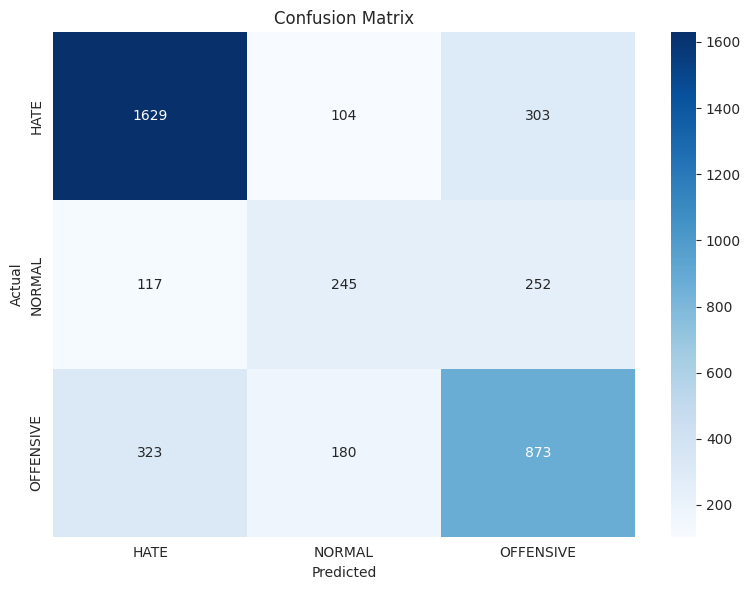


Macro-Averaged AUC: 0.8285
95% CI for Macro-Averaged AUC: [0.8181, 0.8388]
Saved ROC curve to: /content/drive/MyDrive/NLP_Projects/HateSpeech/4o_mini/GRU Model_roc_curve.png


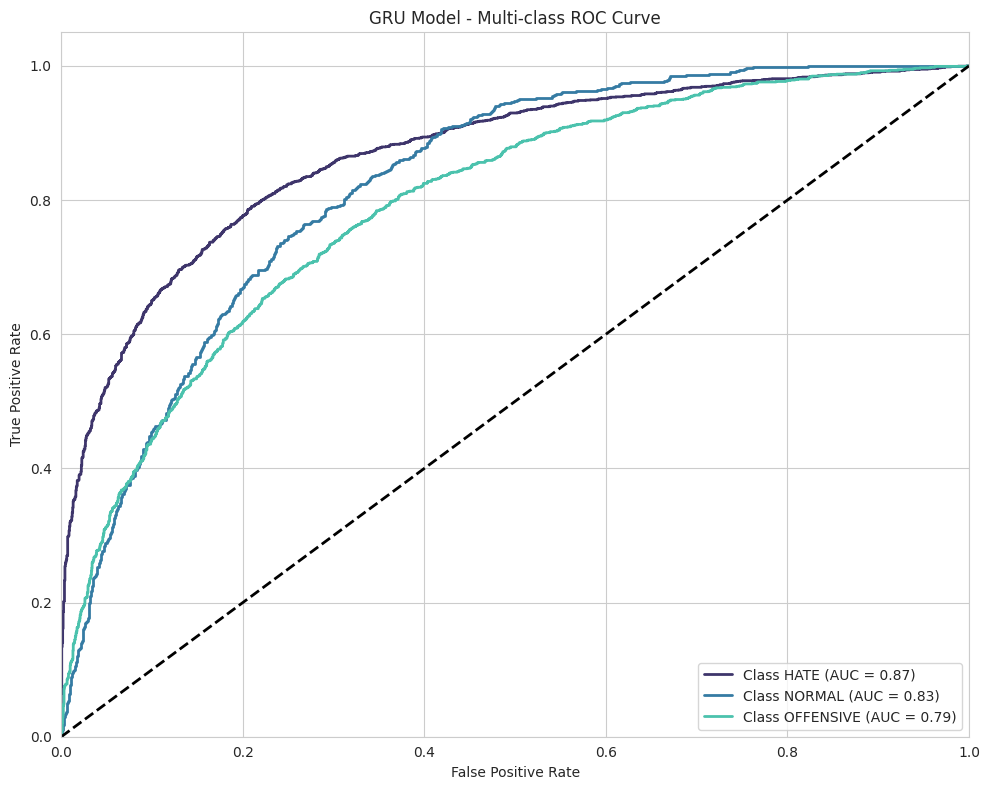

In [ ]:
# Evaluate the best model on the test set
best_gru.eval()
test_predictions_gru, test_labels_gru = [], []
test_probabilities_gru = []

with torch.no_grad():
    for batch in test_loader_gru:
        input_ids = batch["input_ids"].to(device)
        labels = batch["label"].to(device)

        # Forward pass
        outputs = best_gru(input_ids)

        # Apply softmax to get probabilities for all classes
        probs = torch.softmax(outputs, dim = 1)
        test_probabilities_gru.extend(probs.cpu().numpy())  # Collect probabilities for all classes

        # Collect predictions and labels (unchanged)
        preds = torch.argmax(probs, dim = 1)
        test_predictions_gru.extend(preds.cpu().numpy())
        test_labels_gru.extend(labels.cpu().numpy())

evaluate_pytorch_multiclass(
    model = best_gru,
    test_loader = test_loader_gru,
    device = device,
    label_encoder = label_encoder,
    model_name = "GRU Model",
    use_attention_mask = False  # <-- This is the key part for the GRU
)

#### Step 5: Model Interpretation

Example vocab mappings (idx2word): [(1, 'the'), (2, 'a'), (3, 'to'), (4, 'and'), (5, 'i'), (6, 'user'), (7, 'you'), (8, 'of'), (9, 'is'), (10, 'not')]
GRU validation tensor shape: torch.Size([4026, 57])
Baseline weighted F1 on GRU validation: 0.6840
Will compute permutation importance for these token IDs (most frequent):
[ 1  2  3  4  5  6  7  8  9 11 12 13 10 14 16 15 17 18 19 22] ...
Token ID 1 ('the'): perturbed F1=0.6829, ΔF1=0.0011
Token ID 2 ('a'): perturbed F1=0.6839, ΔF1=0.0001
Token ID 3 ('to'): perturbed F1=0.6897, ΔF1=-0.0057
Token ID 4 ('and'): perturbed F1=0.6832, ΔF1=0.0009
Token ID 5 ('i'): perturbed F1=0.6819, ΔF1=0.0021
Token ID 6 ('user'): perturbed F1=0.6844, ΔF1=-0.0003
Token ID 7 ('you'): perturbed F1=0.6808, ΔF1=0.0032
Token ID 8 ('of'): perturbed F1=0.6817, ΔF1=0.0024
Token ID 9 ('is'): perturbed F1=0.6826, ΔF1=0.0014
Token ID 11 ('in'): perturbed F1=0.6849, ΔF1=-0.0009
Token ID 12 ('are'): perturbed F1=0.6821, ΔF1=0.0019
Token ID 13 ('that'): perturbed F1=0.6821

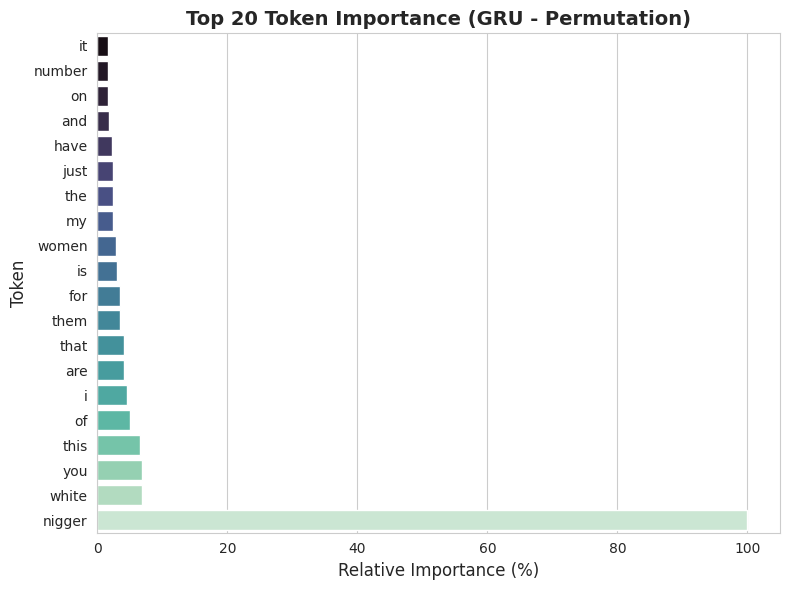

In [ ]:
# ==============================
# 1. Config and vocab mapping
# ==============================

# Your vocab dict: {word: index}
# If your dict has a different name, change this line accordingly.
vocab_dict = word_to_index

# Build reverse lookup: index -> word
idx2word = {idx: word for word, idx in vocab_dict.items()}
print("Example vocab mappings (idx2word):", list(idx2word.items())[:10])

# IMPORTANT: set this to your actual PAD index (often 0)
PAD_IDX = 0

# Number of tokens to evaluate for permutation importance
TOP_TOKENS = 50

# ==============================
# 2. Collect validation inputs / labels for GRU
# ==============================

best_gru.eval()
best_gru.to(device)

val_input_ids_list = []
val_labels_list = []

with torch.no_grad():
    for batch in val_loader_gru:
        val_input_ids_list.append(batch["input_ids"])
        val_labels_list.append(batch["label"])

val_input_ids = torch.cat(val_input_ids_list, dim = 0)   # [N, L]
val_labels = torch.cat(val_labels_list, dim = 0)      # [N]
val_labels_np = val_labels.cpu().numpy()

print("GRU validation tensor shape:", val_input_ids.shape)

# ==============================
# 3. Helper: run GRU on a given tensor
# ==============================

def gru_preds_from_ids(input_ids_tensor):
    """
    Given a [N, L] tensor of token IDs, return numpy array of predictions
    from best_gru.
    """
    with torch.no_grad():
        logits = best_gru(input_ids_tensor.to(device))
        # If some wrapper returns an object with .logits, handle that:
        if hasattr(logits, "logits"):
            logits = logits.logits
        preds = torch.argmax(logits, dim = 1).cpu().numpy()
    return preds

# Baseline F1 on unperturbed validation data
baseline_preds_gru = gru_preds_from_ids(val_input_ids)
baseline_f1_gru    = f1_score(val_labels_np, baseline_preds_gru, average="weighted")

print(f"Baseline weighted F1 on GRU validation: {baseline_f1_gru:.4f}")

# ==============================
# 4. Choose which tokens to perturb (most frequent in validation)
# ==============================

vals_np = val_input_ids.cpu().numpy().ravel()
unique_ids, counts = np.unique(vals_np, return_counts=True)

# Sort by frequency (descending)
order = np.argsort(-counts)
unique_ids = unique_ids[order]
counts = counts[order]

# Drop PAD from candidates
mask_not_pad = unique_ids != PAD_IDX
unique_ids = unique_ids[mask_not_pad]
counts = counts[mask_not_pad]

candidate_token_ids = unique_ids[:TOP_TOKENS]
print("Will compute permutation importance for these token IDs (most frequent):")
print(candidate_token_ids[:20], "...")

# ==============================
# 5. Permutation importance by masking tokens
# ==============================

token_importances_gru = []  # list of dicts for DataFrame

for tok_id in candidate_token_ids:
    tok_id = int(tok_id)

    # Where does this token appear in validation?
    mask = (val_input_ids == tok_id)

    # If it never appears (edge case), skip
    if not mask.any():
        continue

    # Make a perturbed copy: replace this token with PAD everywhere
    perturbed_ids = val_input_ids.clone()
    perturbed_ids[mask] = PAD_IDX

    # Compute F1 with perturbed inputs
    perturbed_preds = gru_preds_from_ids(perturbed_ids)
    perturbed_f1 = f1_score(val_labels_np, perturbed_preds, average="weighted")

    delta_f1 = baseline_f1_gru - perturbed_f1

    # Map ID -> word, fallback to <tok_id> if unseen
    token_str = idx2word.get(tok_id, f"<tok_{tok_id}>")

    token_importances_gru.append({
        "Feature": token_str,
        "Importance": delta_f1
    })

    print(f"Token ID {tok_id} ('{token_str}'): "
          f"perturbed F1={perturbed_f1:.4f}, ΔF1={delta_f1:.4f}")

print("\nComputed permutation importance for", len(token_importances_gru), "tokens (GRU).")

# ==============================
# 6. Build DataFrame and plot top 20
# ==============================

importance_df_gru = pd.DataFrame(token_importances_gru)

# Clip any tiny negatives to 0
importance_df_gru["Importance"] = importance_df_gru["Importance"].clip(lower=0)

# Normalize to 0–100 for "Relative Importance (%)"
if importance_df_gru["Importance"].max() > 0:
    importance_df_gru["Scaled Importance"] = (
        importance_df_gru["Importance"] / importance_df_gru["Importance"].max()
    ) * 100
else:
    importance_df_gru["Scaled Importance"] = 0.0

# Sort and take top 20 tokens
top_20_gru = importance_df_gru.sort_values(
    by = "Importance", ascending = False
).head(20)

print("\nTop 20 token importances for GRU:")
print(top_20_gru[["Feature", "Importance", "Scaled Importance"]])

# Plot (same style as LR and CNN)
plt.figure(figsize=(8, 6))
sns.set_style("whitegrid")
sns.barplot(
    x = "Scaled Importance",
    y = "Feature",
    data = top_20_gru[::-1],   # reverse so most important is at top
    orient = "h",
    palette = "mako"
)

plt.title("Top 20 Token Importance (GRU - Permutation)", fontsize = 14, fontweight = "bold")
plt.xlabel("Relative Importance (%)", fontsize = 12)
plt.ylabel("Token", fontsize = 12)
plt.xticks(fontsize = 10)
plt.yticks(fontsize = 10)
plt.tight_layout()

gru_imp_fig_path = os.path.join(DRIVE_PROJECT_PATH, "gru_token_importance_top20.png")
plt.savefig(gru_imp_fig_path, dpi = 300)
plt.show()

## 4.2 CNN

### 4.2.1 Data Preprocessing

#### Step 1: Copy data for CNN modeling

In [ ]:
df_cnn = df_clean.copy()

#### Step 2: Build train/val/test splits for CNN

In [ ]:
# Use the master split directly
df_train_cnn = df_cnn[df_cnn["split"]=="train"].copy()
df_val_cnn   = df_cnn[df_cnn["split"]=="val"].copy()
df_test_cnn  = df_cnn[df_cnn["split"]=="test"].copy()

print("CNN split sizes:",
      len(df_train_cnn), len(df_val_cnn), len(df_test_cnn))

# Texts and labels for CNN (use cleaned master text)
train_texts_cnn = df_train_cnn[TEXT_COLUMN].tolist()
train_labels_cnn = df_train_cnn[LABEL_COLUMN_ENCODED].tolist()

val_texts_cnn = df_val_cnn[TEXT_COLUMN].tolist()
val_labels_cnn = df_val_cnn[LABEL_COLUMN_ENCODED].tolist()

test_texts_cnn = df_test_cnn[TEXT_COLUMN].tolist()
test_labels_cnn = df_test_cnn[LABEL_COLUMN_ENCODED].tolist()

CNN split sizes: 12096 4026 4026


#### Step 3: Prepare the data for GRU model

In [ ]:
# Build vocabulary on training data only
all_train_words_cnn = " ".join(train_texts_cnn).split()
most_common_words_cnn = [w for w, _ in Counter(all_train_words_cnn).most_common(VOCAB_SIZE - 1)]
word_to_index_cnn = {word: idx + 1 for idx, word in enumerate(most_common_words_cnn)}  # 0 = PAD

def text_to_sequence_cnn(text, word_to_index, max_len=MAX_TOKEN_LENGTH):
    tokens = text.split()
    seq = [word_to_index.get(tok, 0) for tok in tokens]
    return seq[:max_len]

# Convert text to sequences
train_sequences_cnn = [text_to_sequence_cnn(t, word_to_index_cnn) for t in train_texts_cnn]
val_sequences_cnn = [text_to_sequence_cnn(t, word_to_index_cnn) for t in val_texts_cnn]
test_sequences_cnn = [text_to_sequence_cnn(t, word_to_index_cnn) for t in test_texts_cnn]

# Pad sequences
def pad_sequences(seqs):
    return nn.utils.rnn.pad_sequence(
        [torch.tensor(s, dtype = torch.long) for s in seqs],
        batch_first = True,
        padding_value = 0
    )

train_sequences_cnn = pad_sequences(train_sequences_cnn)
val_sequences_cnn = pad_sequences(val_sequences_cnn)
test_sequences_cnn = pad_sequences(test_sequences_cnn)

# Convert labels to tensors
train_labels_cnn = torch.tensor(train_labels_cnn, dtype = torch.long)
val_labels_cnn = torch.tensor(val_labels_cnn, dtype = torch.long)
test_labels_cnn = torch.tensor(test_labels_cnn, dtype = torch.long)

# Create Datasets and DataLoaders
class SentimentDatasetCNN(Dataset):
    def __init__(self, texts, labels):
        self.texts = texts
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids": self.texts[idx],
            "label": self.labels[idx]
        }

train_dataset_cnn = SentimentDatasetCNN(train_sequences_cnn, train_labels_cnn)
val_dataset_cnn = SentimentDatasetCNN(val_sequences_cnn, val_labels_cnn)
test_dataset_cnn = SentimentDatasetCNN(test_sequences_cnn, test_labels_cnn)

train_loader_cnn = DataLoader(train_dataset_cnn, batch_size = BATCH_SIZE, shuffle = True)
val_loader_cnn = DataLoader(val_dataset_cnn, batch_size = BATCH_SIZE, shuffle = False)
test_loader_cnn = DataLoader(test_dataset_cnn, batch_size = BATCH_SIZE, shuffle = False)

### 4.2.2 CNN Modeling

#### Step 1: Define CNN Model

In [ ]:
class CNNSentimentModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, num_filters, output_dim,
                 kernel_sizes=(3, 4, 5), dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        self.convs = nn.ModuleList([
            nn.Conv1d(
                in_channels=embedding_dim,
                out_channels=num_filters,
                kernel_size=k
            ) for k in kernel_sizes
        ])

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(num_filters * len(kernel_sizes), output_dim)

    def forward(self, input_ids):
        # input_ids: [B, T]
        embedded = self.embedding(input_ids)          # [B, T, E]
        embedded = embedded.permute(0, 2, 1)          # [B, E, T]

        conv_outs = []
        for conv in self.convs:
            x = conv(embedded)                        # [B, F, T']
            x = torch.relu(x)
            x = torch.max_pool1d(x, kernel_size=x.size(2))  # [B, F, 1]
            x = x.squeeze(2)                          # [B, F]
            conv_outs.append(x)

        cat = torch.cat(conv_outs, dim = 1)             # [B, F * len(kernel_sizes)]
        out = self.fc(self.dropout(cat))              # [B, C]
        return out

#### Step 2: Hyperparameter Tuning

In [ ]:
SEED = 2025
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

MAX_EPOCHS = 20
PATIENCE = 5

# Class weights from training labels
train_labels_np_cnn = train_labels_cnn.numpy()
class_weights_cnn = compute_class_weight(
    class_weight = "balanced",
    classes = np.unique(train_labels_np_cnn),
    y=train_labels_np_cnn
)
class_weights_tensor_cnn = torch.tensor(class_weights_cnn, dtype = torch.float32).to(device)

def train_and_evaluate_cnn(hyperparams, train_loader, val_loader, vocab_size, output_dim,
                           device, class_weights_tensor, max_epochs = 20, patience = 5):

    embedding_dim = int(hyperparams["embedding_dim"])
    num_filters = int(hyperparams["num_filters"])
    lr = hyperparams["lr"]

    model = CNNSentimentModel(
        vocab_size = vocab_size,
        embedding_dim = embedding_dim,
        num_filters = num_filters,
        output_dim = output_dim,
        kernel_sizes = (3, 4, 5),
        dropout = 0.5
    ).to(device)

    criterion = nn.CrossEntropyLoss(weight = class_weights_tensor)
    optimizer = torch.optim.Adam(model.parameters(), lr = lr)

    best_val_f1 = -1.0
    best_val_acc = 0.0
    best_state_dict = None
    epochs_no_improve = 0

    for epoch in range(max_epochs):
        # ----- TRAIN -----
        model.train()
        total_loss = 0.0

        for batch in train_loader:
            input_ids = batch["input_ids"].to(device)
            labels = batch["label"].to(device)

            optimizer.zero_grad()
            outputs = model(input_ids)
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm = 5.0)
            optimizer.step()

            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)

        # ----- VALIDATE -----
        model.eval()
        val_preds, val_true = [], []
        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch["input_ids"].to(device)
                labels = batch["label"].to(device)

                outputs = model(input_ids)
                preds = torch.argmax(outputs, dim = 1)

                val_preds.extend(preds.cpu().numpy())
                val_true.extend(labels.cpu().numpy())

        val_f1 = f1_score(val_true, val_preds, average = "weighted")
        val_acc = accuracy_score(val_true, val_preds)

        print(
            f"[CNN] Epoch {epoch+1}/{max_epochs} | "
            f"Train Loss: {avg_train_loss:.4f} | "
            f"Val F1: {val_f1:.4f} | Val Acc: {val_acc:.4f}"
        )

        # ----- EARLY STOPPING -----
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_val_acc = val_acc
            best_state_dict = model.state_dict()
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"[CNN] No improvement for {patience} epochs. Early stopping at epoch {epoch+1}.")
                break

    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)

    return best_val_f1, best_val_acc, model


# Random search for CNN
def random_hyperparameter_tuning_cnn(train_loader, val_loader, vocab_size, output_dim,
                                     device, class_weights_tensor, n_iter = N_ITERATIONS):

    param_space = {
        "embedding_dim": (150, 300),     # uniform
        "num_filters":  (80, 200),       # filters per kernel size
        "lr": (np.log10(1e-4), np.log10(1e-3)),  # log-uniform
    }

    best_f1 = -1.0
    best_params = None
    best_model = None

    with tqdm(total=n_iter, desc = "Random Search (CNN)", leave = True) as pbar:
        for _ in range(n_iter):
            hyperparams = {
                "embedding_dim": np.random.uniform(*param_space["embedding_dim"]),
                "num_filters": np.random.uniform(*param_space["num_filters"]),
                "lr": 10 ** np.random.uniform(*param_space["lr"]),
            }

            f1_val, acc_val, model = train_and_evaluate_cnn(
                hyperparams, train_loader, val_loader, vocab_size, output_dim,
                device, class_weights_tensor, max_epochs = MAX_EPOCHS, patience = PATIENCE
            )

            pbar.set_postfix(f1 = f1_val, acc = acc_val)
            pbar.update(1)

            if f1_val > best_f1:
                best_f1 = f1_val
                best_params = hyperparams
                best_model = model

    print(f"\n[CNN] Best Validation F1: {best_f1:.4f}")
    print(f"[CNN] Best Hyperparameters: {best_params}")

    # Save best model + params
    torch.save(best_model.state_dict(), BEST_CNN_PATH)
    with open(BEST_CNN_PARAMS_PATH, "w") as f:
        json.dump(best_params, f)

    return best_params, best_f1, best_model

# Run CNN tuning
start_time = time.time()

best_params_cnn, best_f1_cnn, best_model_cnn = random_hyperparameter_tuning_cnn(
    train_loader = train_loader_cnn, val_loader = val_loader_cnn, vocab_size = VOCAB_SIZE, output_dim = NUM_CLASSES,
    device = device, class_weights_tensor = class_weights_tensor_cnn,
    n_iter = N_ITERATIONS
)

end_time = time.time()
print(f"Total CNN tuning time: {end_time - start_time:.2f} seconds")

Random Search (CNN):   0%|          | 0/10 [00:00<?, ?it/s]

[CNN] Epoch 1/20 | Train Loss: 1.0442 | Val F1: 0.5698 | Val Acc: 0.5740
[CNN] Epoch 2/20 | Train Loss: 0.8015 | Val F1: 0.6519 | Val Acc: 0.6401
[CNN] Epoch 3/20 | Train Loss: 0.6614 | Val F1: 0.6553 | Val Acc: 0.6408
[CNN] Epoch 4/20 | Train Loss: 0.5417 | Val F1: 0.6545 | Val Acc: 0.6366
[CNN] Epoch 5/20 | Train Loss: 0.4419 | Val F1: 0.6621 | Val Acc: 0.6490
[CNN] Epoch 6/20 | Train Loss: 0.3482 | Val F1: 0.6826 | Val Acc: 0.6841
[CNN] Epoch 7/20 | Train Loss: 0.2730 | Val F1: 0.6944 | Val Acc: 0.6925
[CNN] Epoch 8/20 | Train Loss: 0.2175 | Val F1: 0.6902 | Val Acc: 0.6913
[CNN] Epoch 9/20 | Train Loss: 0.1832 | Val F1: 0.6818 | Val Acc: 0.6833
[CNN] Epoch 10/20 | Train Loss: 0.1515 | Val F1: 0.6827 | Val Acc: 0.6801
[CNN] Epoch 11/20 | Train Loss: 0.1171 | Val F1: 0.6932 | Val Acc: 0.6932


Random Search (CNN):  10%|█         | 1/10 [00:21<03:16, 21.84s/it, acc=0.692, f1=0.694]

[CNN] Epoch 12/20 | Train Loss: 0.0971 | Val F1: 0.6922 | Val Acc: 0.6910
[CNN] No improvement for 5 epochs. Early stopping at epoch 12.
[CNN] Epoch 1/20 | Train Loss: 1.1190 | Val F1: 0.6132 | Val Acc: 0.6192
[CNN] Epoch 2/20 | Train Loss: 0.9019 | Val F1: 0.6132 | Val Acc: 0.5874
[CNN] Epoch 3/20 | Train Loss: 0.7826 | Val F1: 0.6574 | Val Acc: 0.6468
[CNN] Epoch 4/20 | Train Loss: 0.6894 | Val F1: 0.6399 | Val Acc: 0.6210
[CNN] Epoch 5/20 | Train Loss: 0.6252 | Val F1: 0.6679 | Val Acc: 0.6545
[CNN] Epoch 6/20 | Train Loss: 0.5542 | Val F1: 0.6802 | Val Acc: 0.6734
[CNN] Epoch 7/20 | Train Loss: 0.4953 | Val F1: 0.6748 | Val Acc: 0.6721
[CNN] Epoch 8/20 | Train Loss: 0.4478 | Val F1: 0.6864 | Val Acc: 0.6798
[CNN] Epoch 9/20 | Train Loss: 0.3989 | Val F1: 0.6847 | Val Acc: 0.6818
[CNN] Epoch 10/20 | Train Loss: 0.3586 | Val F1: 0.6851 | Val Acc: 0.6836
[CNN] Epoch 11/20 | Train Loss: 0.3273 | Val F1: 0.6859 | Val Acc: 0.6846
[CNN] Epoch 12/20 | Train Loss: 0.2915 | Val F1: 0.6869 | 

Random Search (CNN):  20%|██        | 2/10 [04:11<19:14, 144.27s/it, acc=0.695, f1=0.693]

...

Random Search (CNN):  90%|█████████ | 9/10 [24:21<02:38, 158.63s/it, acc=0.696, f1=0.697]

[CNN] Epoch 20/20 | Train Loss: 0.0639 | Val F1: 0.6907 | Val Acc: 0.6918
[CNN] Epoch 1/20 | Train Loss: 1.1545 | Val F1: 0.5627 | Val Acc: 0.5462
[CNN] Epoch 2/20 | Train Loss: 0.9869 | Val F1: 0.6261 | Val Acc: 0.6190
[CNN] Epoch 3/20 | Train Loss: 0.8802 | Val F1: 0.6377 | Val Acc: 0.6237
[CNN] Epoch 4/20 | Train Loss: 0.8092 | Val F1: 0.6396 | Val Acc: 0.6242
[CNN] Epoch 5/20 | Train Loss: 0.7450 | Val F1: 0.6518 | Val Acc: 0.6396
[CNN] Epoch 6/20 | Train Loss: 0.7093 | Val F1: 0.6533 | Val Acc: 0.6403
[CNN] Epoch 7/20 | Train Loss: 0.6542 | Val F1: 0.6754 | Val Acc: 0.6687
[CNN] Epoch 8/20 | Train Loss: 0.6039 | Val F1: 0.6795 | Val Acc: 0.6729
[CNN] Epoch 9/20 | Train Loss: 0.5759 | Val F1: 0.6705 | Val Acc: 0.6595
[CNN] Epoch 10/20 | Train Loss: 0.5302 | Val F1: 0.6729 | Val Acc: 0.6637
[CNN] Epoch 11/20 | Train Loss: 0.4984 | Val F1: 0.6783 | Val Acc: 0.6699
[CNN] Epoch 12/20 | Train Loss: 0.4751 | Val F1: 0.6710 | Val Acc: 0.6605
[CNN] Epoch 13/20 | Train Loss: 0.4415 | Val F1

Random Search (CNN): 100%|██████████| 10/10 [28:09<00:00, 168.94s/it, acc=0.687, f1=0.692]

[CNN] Epoch 20/20 | Train Loss: 0.2876 | Val F1: 0.6912 | Val Acc: 0.6883

[CNN] Best Validation F1: 0.7016
[CNN] Best Hyperparameters: {'embedding_dim': 195.01725071169548, 'num_filters': 109.83183640048519, 'lr': 0.00046386553400665334}


Total CNN tuning time: 1691.70 seconds


#### Step 3: Model Construction (Here we load the best model directly)

In [ ]:
with open(BEST_CNN_PARAMS_PATH, "r") as f:
    loaded_best_params_cnn = json.load(f)

embedding_dim_best_cnn = int(loaded_best_params_cnn["embedding_dim"])
num_filters_best_cnn = int(loaded_best_params_cnn["num_filters"])

best_cnn = CNNSentimentModel(
    vocab_size = VOCAB_SIZE,
    embedding_dim = embedding_dim_best_cnn,
    num_filters = num_filters_best_cnn,
    output_dim = NUM_CLASSES,
    kernel_sizes = (3, 4, 5),
    dropout = 0.5
).to(device)

#### Step 4: Model Evaluation

Evaluating CNN Model: 100%|██████████| 126/126 [00:00<00:00, 723.87it/s]



--- Evaluation Report: CNN Model ---

Classification Report:
              precision    recall  f1-score   support

        HATE     0.8013    0.7608    0.7805      2036
      NORMAL     0.4664    0.4967    0.4811       614
   OFFENSIVE     0.6088    0.6366    0.6224      1376

    accuracy                         0.6781      4026
   macro avg     0.6255    0.6314    0.6280      4026
weighted avg     0.6844    0.6781    0.6808      4026

Weighted F1 Score: 0.6809
95% CI for F1 Score: [0.6659, 0.6957]
Saved confusion matrix to: /content/drive/MyDrive/NLP_Projects/HateSpeech/4o_mini/CNN Model_confusion_matrix.png


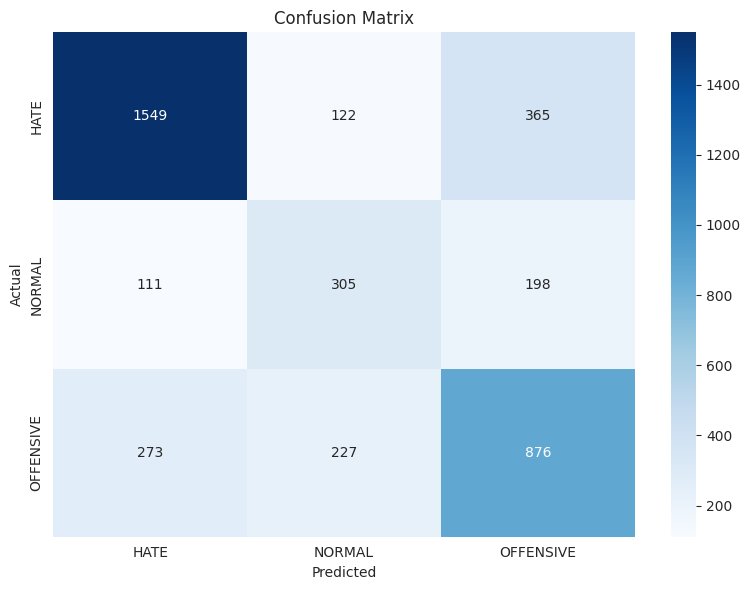


Macro-Averaged AUC: 0.8400
95% CI for Macro-Averaged AUC: [0.8295, 0.8498]
Saved ROC curve to: /content/drive/MyDrive/NLP_Projects/HateSpeech/4o_mini/CNN Model_roc_curve.png


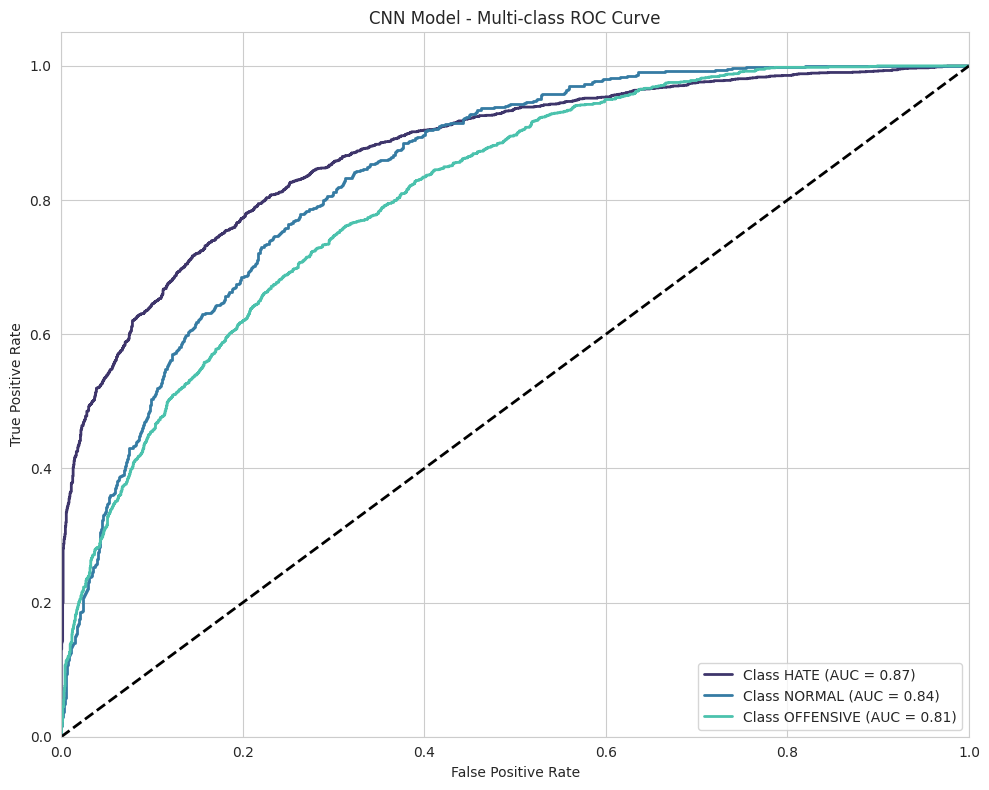

In [ ]:
state_dict_cnn = torch.load(BEST_CNN_PATH, map_location = device)
best_cnn.load_state_dict(state_dict_cnn)
best_cnn.eval()

test_predictions_cnn = []
test_labels_true_cnn = []
test_probabilities_cnn = []

with torch.no_grad():
    for batch in test_loader_cnn:
        input_ids = batch["input_ids"].to(device)
        labels = batch["label"].to(device)

        logits = best_cnn(input_ids)
        probs = torch.softmax(logits, dim = 1)

        test_probabilities_cnn.extend(probs.cpu().numpy())
        preds = torch.argmax(probs, dim = 1)

        test_predictions_cnn.extend(preds.cpu().numpy())
        test_labels_true_cnn.extend(labels.cpu().numpy())

# Use your existing helper for reporting
evaluate_pytorch_multiclass(
    model = best_cnn,
    test_loader = test_loader_cnn,
    device = device,
    label_encoder = label_encoder,
    model_name = "CNN Model",
    use_attention_mask = False
)

#### Step 5: Model Interpretation

Example vocab mappings (idx2word): [(1, 'the'), (2, 'a'), (3, 'to'), (4, 'and'), (5, 'i'), (6, 'user'), (7, 'you'), (8, 'of'), (9, 'is'), (10, 'not')]
CNN validation tensor shape: torch.Size([4026, 57])
Baseline weighted F1 on CNN validation: 0.6955
Will compute permutation importance for these token IDs (most frequent):
[ 1  2  3  4  5  6  7  8  9 11 12 13 10 14 16 15 17 18 19 22] ...
Token ID 1 ('the'): perturbed F1=0.6896, ΔF1=0.0059
Token ID 2 ('a'): perturbed F1=0.6938, ΔF1=0.0018
Token ID 3 ('to'): perturbed F1=0.6965, ΔF1=-0.0010
Token ID 4 ('and'): perturbed F1=0.6946, ΔF1=0.0010
Token ID 5 ('i'): perturbed F1=0.6938, ΔF1=0.0018
Token ID 6 ('user'): perturbed F1=0.6961, ΔF1=-0.0005
Token ID 7 ('you'): perturbed F1=0.6932, ΔF1=0.0024
Token ID 8 ('of'): perturbed F1=0.6945, ΔF1=0.0010
Token ID 9 ('is'): perturbed F1=0.6984, ΔF1=-0.0029
Token ID 11 ('in'): perturbed F1=0.6968, ΔF1=-0.0012
Token ID 12 ('are'): perturbed F1=0.6929, ΔF1=0.0027
Token ID 13 ('that'): perturbed F1=0.694

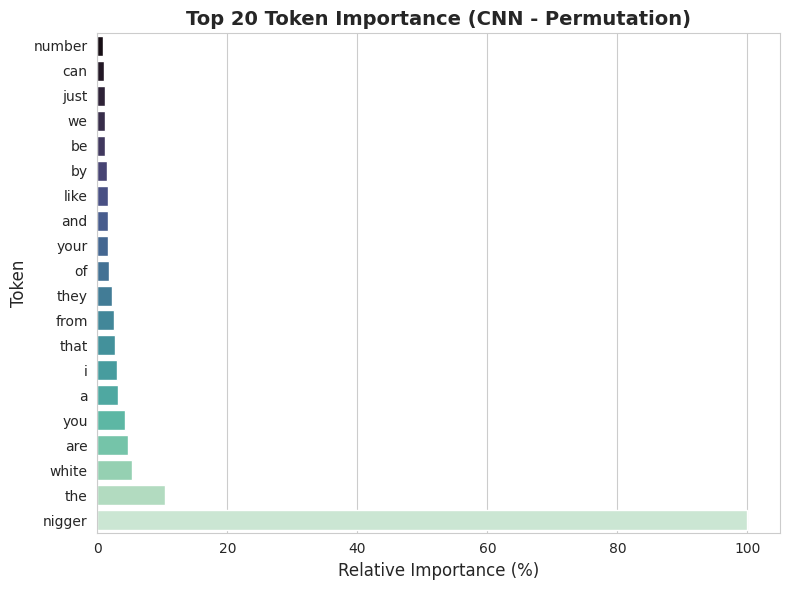

In [ ]:
# ==============================
# 1. Config and vocab mapping
# ==============================

# Your vocab dict: {word: index}
# If your dict has a different name, change this line accordingly.
vocab_dict = word_to_index

# Build reverse lookup: index -> word
idx2word = {idx: word for word, idx in vocab_dict.items()}
print("Example vocab mappings (idx2word):", list(idx2word.items())[:10])

# IMPORTANT: set this to your actual PAD index (often 0)
PAD_IDX = 0

# Number of tokens to evaluate for permutation importance
TOP_TOKENS = 50

# ==============================
# 2. Collect validation inputs / labels for CNN
# ==============================

best_cnn.eval()
best_cnn.to(device)

val_input_ids_list = []
val_labels_list = []

with torch.no_grad():
    for batch in val_loader_cnn:
        val_input_ids_list.append(batch["input_ids"])
        val_labels_list.append(batch["label"])

val_input_ids = torch.cat(val_input_ids_list, dim = 0)   # [N, L]
val_labels = torch.cat(val_labels_list, dim = 0)      # [N]
val_labels_np = val_labels.cpu().numpy()

print("CNN validation tensor shape:", val_input_ids.shape)

# ==============================
# 3. Helper: run CNN on a given tensor
# ==============================

def cnn_preds_from_ids(input_ids_tensor):
    """
    Given a [N, L] tensor of token IDs, return numpy array of predictions
    from best_cnn.
    """
    with torch.no_grad():
        logits = best_cnn(input_ids_tensor.to(device))
        # In case your CNN wrapper returns an object with .logits, handle that:
        if hasattr(logits, "logits"):
            logits = logits.logits
        preds = torch.argmax(logits, dim = 1).cpu().numpy()
    return preds

# Baseline F1 on unperturbed validation data
baseline_preds_cnn = cnn_preds_from_ids(val_input_ids)
baseline_f1_cnn = f1_score(val_labels_np, baseline_preds_cnn, average="weighted")

print(f"Baseline weighted F1 on CNN validation: {baseline_f1_cnn:.4f}")

# ==============================
# 4. Choose which tokens to perturb (most frequent in validation)
# ==============================

vals_np = val_input_ids.cpu().numpy().ravel()
unique_ids, counts = np.unique(vals_np, return_counts=True)

# Sort by frequency (descending)
order = np.argsort(-counts)
unique_ids = unique_ids[order]
counts = counts[order]

# Drop PAD from candidates
mask_not_pad = unique_ids != PAD_IDX
unique_ids = unique_ids[mask_not_pad]
counts = counts[mask_not_pad]

candidate_token_ids = unique_ids[:TOP_TOKENS]
print("Will compute permutation importance for these token IDs (most frequent):")
print(candidate_token_ids[:20], "...")

# ==============================
# 5. Permutation importance by masking tokens
# ==============================

token_importances = []  # list of dicts for DataFrame

for tok_id in candidate_token_ids:
    tok_id = int(tok_id)

    # Where does this token appear in validation?
    mask = (val_input_ids == tok_id)

    # If it never appears (edge case), skip
    if not mask.any():
        continue

    # Make a perturbed copy: replace this token with PAD everywhere
    perturbed_ids = val_input_ids.clone()
    perturbed_ids[mask] = PAD_IDX

    # Compute F1 with perturbed inputs
    perturbed_preds = cnn_preds_from_ids(perturbed_ids)
    perturbed_f1 = f1_score(val_labels_np, perturbed_preds, average="weighted")

    delta_f1 = baseline_f1_cnn - perturbed_f1

    # Map ID -> word, fallback to <tok_id> if unseen
    token_str = idx2word.get(tok_id, f"<tok_{tok_id}>")

    token_importances.append({
        "Feature": token_str,
        "Importance": delta_f1
    })

    print(f"Token ID {tok_id} ('{token_str}'): "
          f"perturbed F1={perturbed_f1:.4f}, ΔF1={delta_f1:.4f}")

print("\nComputed permutation importance for", len(token_importances), "tokens (CNN).")

# ==============================
# 6. Build DataFrame and plot top 20 (LR-style)
# ==============================

importance_df_cnn = pd.DataFrame(token_importances)

# Clip any tiny negatives to 0
importance_df_cnn["Importance"] = importance_df_cnn["Importance"].clip(lower=0)

# Normalize to 0–100 for "Relative Importance (%)"
if importance_df_cnn["Importance"].max() > 0:
    importance_df_cnn["Scaled Importance"] = (
        importance_df_cnn["Importance"] / importance_df_cnn["Importance"].max()
    ) * 100
else:
    importance_df_cnn["Scaled Importance"] = 0.0

# Sort and take top 20 tokens
top_20_cnn = importance_df_cnn.sort_values(
    by = "Importance", ascending = False
).head(20)

print("\nTop 20 token importances for CNN:")
print(top_20_cnn[["Feature", "Importance", "Scaled Importance"]])

# Plot (same style as LR)
plt.figure(figsize=(8, 6))
sns.set_style("whitegrid")
sns.barplot(
    x = "Scaled Importance",
    y = "Feature",
    data = top_20_cnn[::-1],   # reverse so most important is at top
    orient = "h",
    palette = "mako"
)

plt.title("Top 20 Token Importance (CNN - Permutation)", fontsize = 14, fontweight = "bold")
plt.xlabel("Relative Importance (%)", fontsize = 12)
plt.ylabel("Token", fontsize = 12)
plt.xticks(fontsize = 10)
plt.yticks(fontsize = 10)
plt.tight_layout()

cnn_imp_fig_path = os.path.join(DRIVE_PROJECT_PATH, "cnn_token_importance_top20.png")
plt.savefig(cnn_imp_fig_path, dpi = 300)
plt.show()

## 4.3 Albert

### 4.3.1 Data Preprocessing

#### Step 1: Copy clean data for ALBERT model

In [ ]:
df_albert = df_clean.copy()

#### Step 2: Build train/val/test splits for ALBERT


In [ ]:
# Use the master split directly
df_train_albert = df_albert[df_albert["split"] == "train"].copy()
df_val_albert   = df_albert[df_albert["split"] == "val"].copy()
df_test_albert  = df_albert[df_albert["split"] == "test"].copy()

print("GRU split sizes:",
      len(df_train_albert), len(df_val_albert), len(df_test_albert))

# Texts and labels for ALBERT (use cleaned master text)
train_texts_albert = df_train_albert[TEXT_COLUMN].tolist()
train_labels_albert = df_train_albert[LABEL_COLUMN_ENCODED].tolist()

val_texts_albert = df_val_albert[TEXT_COLUMN].tolist()
val_labels_albert = df_val_albert[LABEL_COLUMN_ENCODED].tolist()

test_texts_albert = df_test_albert[TEXT_COLUMN].tolist()
test_labels_albert = df_test_albert[LABEL_COLUMN_ENCODED].tolist()

GRU split sizes: 12096 4026 4026


#### Step 3: Prepare the data for ALBERT model

In [ ]:
# Load tokenizer
tokenizer = AlbertTokenizer.from_pretrained("albert-base-v2")

# Create Dataset objects
class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = list(texts)  # Ensure texts is a list of strings
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = MAX_TOKEN_LENGTH

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        text = str(self.texts[idx])  # Ensure each text is a string
        label = self.labels[idx]
        encoding = self.tokenizer(
            text,
            truncation = True,
            padding = "max_length",
            max_length = self.max_len,
            return_tensors = "pt"
        )
        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "label": torch.tensor(label, dtype = torch.long)
        }

train_dataset_albert = SentimentDataset(train_texts_albert, train_labels_albert, tokenizer, MAX_TOKEN_LENGTH)
test_dataset_albert = SentimentDataset(test_texts_albert, test_labels_albert, tokenizer, MAX_TOKEN_LENGTH)
val_dataset_albert = SentimentDataset(val_texts_albert,val_labels_albert,tokenizer, MAX_TOKEN_LENGTH)


# Create DataLoaders
train_loader_albert = DataLoader(train_dataset_albert, batch_size = BATCH_SIZE, shuffle = True)
val_loader_albert = DataLoader(val_dataset_albert, batch_size = BATCH_SIZE)
test_loader_albert = DataLoader(test_dataset_albert, batch_size = BATCH_SIZE)

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/760k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.31M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/684 [00:00<?, ?B/s]

### 4.3.2 ALBERT Modeling

#### Step 1: Hyperparameter Tuning

In [ ]:
SEED = 2025
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

def random_hyperparameter_tuning(train_loader, val_loader, train_labels, n_iter = N_ITERATIONS):
    """
    Performs random search for hyperparameter tuning.

    Args:
        train_loader (DataLoader): DataLoader for the training set.
        val_loader (DataLoader): DataLoader for the validation set.
        train_labels (list or np.array): The raw training labels, needed for class_weight.
        n_iter (int): Number of tuning iterations.
    """
    # Define hyperparameter ranges
    param_space = {
    "lr": (np.log10(1e-5), np.log10(3e-5)),  # 1e-5 to 3e-5
    "epochs": (3, 6),                        # allow up to 6
    "dropout": (0.0, 0.25)                   # modest dropout
    }

    best_f1 = 0
    best_params = None
    best_model = None

    # Compute class weights for class imbalance
    class_weights = compute_class_weight(class_weight = "balanced", classes = np.unique(train_labels), y = train_labels)
    class_weights = torch.tensor(class_weights, dtype = torch.float).to(device)

    # Progress bar for random search iterations
    with tqdm(total = n_iter, desc = "Random Search Tuning", leave = True) as pbar:
        for _ in range(n_iter):
            # Randomly sample hyperparameters
            hyperparams = {
                "lr": 10**np.random.uniform(*param_space["lr"]),
                "epochs": np.random.randint(*param_space["epochs"]),
                "dropout": np.random.uniform(*param_space["dropout"])
            }

            # Initialize model with 8 labels and dropout
            model = AlbertForSequenceClassification.from_pretrained(
                "albert-base-v2",
                num_labels = NUM_CLASSES,
                hidden_dropout_prob = hyperparams["dropout"]
            ).to(device)

            optimizer = AdamW(model.parameters(), lr = hyperparams["lr"])
            criterion = torch.nn.CrossEntropyLoss(weight = class_weights)

            # Training loop
            for epoch in range(hyperparams["epochs"]):
                model.train()
                # Use the "train_loader" argument
                for batch in train_loader:
                    input_ids = batch["input_ids"].to(device)
                    attention_mask = batch["attention_mask"].to(device)
                    labels = batch["label"].to(device)

                    optimizer.zero_grad()
                    outputs = model(input_ids, attention_mask = attention_mask)
                    loss = criterion(outputs.logits, labels)
                    loss.backward()
                    optimizer.step()

            # Validation evaluation
            model.eval()
            val_predictions, val_labels_batch = [], []
            with torch.no_grad():
                # Use the "val_loader" argument
                for batch in val_loader:
                    input_ids = batch["input_ids"].to(device)
                    attention_mask = batch["attention_mask"].to(device)
                    labels = batch["label"].to(device)

                    outputs = model(input_ids, attention_mask = attention_mask)
                    preds = torch.argmax(outputs.logits, dim = 1)
                    val_predictions.extend(preds.cpu().numpy())
                    val_labels_batch.extend(labels.cpu().numpy())

            # Calculate F1-score
            f1 = f1_score(val_labels_batch, val_predictions, average = "weighted")
            accuracy = accuracy_score(val_labels_batch, val_predictions)

            # Update best model
            if f1 > best_f1:
                best_f1 = f1
                best_params = hyperparams
                best_model = model
                # Save the best model
                model_save_path = BEST_ALBERT_PATH
                torch.save(model.state_dict(), model_save_path)

            # Update progress bar
            pbar.set_postfix(f1 = f1, accuracy = accuracy)
            pbar.update(1)

    print(f"\nBest F1 Score: {best_f1:.4f}")
    print(f"Best Hyperparameters: {best_params}")
    return best_params, best_f1, best_model

start_time = time.time()
best_params, best_f1, best_model = random_hyperparameter_tuning(
    train_loader = train_loader_albert,
    val_loader = val_loader_albert,
    train_labels = train_labels_albert,
    n_iter = N_ITERATIONS
)
end_time = time.time()
total_time = end_time - start_time
print(f"Total Parameter Tuning Time: {total_time:.2f} seconds")

Random Search Tuning:   0%|          | 0/10 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/47.4M [00:00<?, ?B/s]

Some weights of AlbertForSequenceClassification were not initialized from the model checkpoint at albert-base-v2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Random Search Tuning:  10%|█         | 1/10 [36:18<5:26:42, 2178.01s/it, accuracy=0.732, f1=0.732]Some weights of AlbertForSequenceClassification were not initialized from the model checkpoint at albert-base-v2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Random Search Tuning:  20%|██        | 2/10 [58:22<3:43:28, 1676.04s/it, accuracy=0.61, f1=0.612]Some weights of AlbertForSequenceClassification were not initialized from the model checkpoint at albert-base-v2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on 


Best F1 Score: 0.7586
Best Hyperparameters: {'lr': 1.9565016249188867e-05, 'epochs': 3, 'dropout': 0.019561457075392835}
Total Parameter Tuning Time: 17877.84 seconds


#### Step 2: Model Construction (Here we load the best model directly)

In [ ]:
best_albert = AlbertForSequenceClassification.from_pretrained("albert-base-v2", num_labels = NUM_CLASSES)
best_albert.load_state_dict(torch.load(BEST_ALBERT_PATH, map_location = device))
best_albert.to(device)

tokenizer = AlbertTokenizer.from_pretrained("albert-base-v2")

Some weights of AlbertForSequenceClassification were not initialized from the model checkpoint at albert-base-v2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


#### Step 3: Model Evaluation

Test F-1 Score: 0.7509, Test Accuracy: 0.7534


Evaluating ALBERT: 100%|██████████| 126/126 [00:53<00:00,  2.38it/s]



--- Evaluation Report: ALBERT ---

Classification Report:
              precision    recall  f1-score   support

        HATE     0.8234    0.8703    0.8462      2036
      NORMAL     0.6010    0.6010    0.6010       614
   OFFENSIVE     0.7079    0.6483    0.6768      1376

    accuracy                         0.7534      4026
   macro avg     0.7108    0.7065    0.7080      4026
weighted avg     0.7500    0.7534    0.7509      4026

Weighted F1 Score: 0.7508
95% CI for F1 Score: [0.7368, 0.7640]
Saved confusion matrix to: /content/drive/MyDrive/NLP_Projects/HateSpeech/4o_mini/ALBERT_confusion_matrix.png


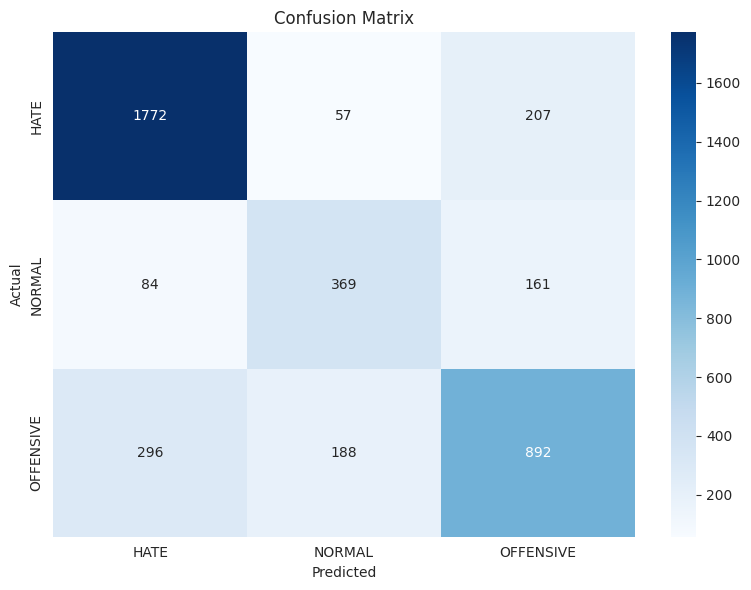


Macro-Averaged AUC: 0.8987
95% CI for Macro-Averaged AUC: [0.8910, 0.9065]
Saved ROC curve to: /content/drive/MyDrive/NLP_Projects/HateSpeech/4o_mini/ALBERT_roc_curve.png


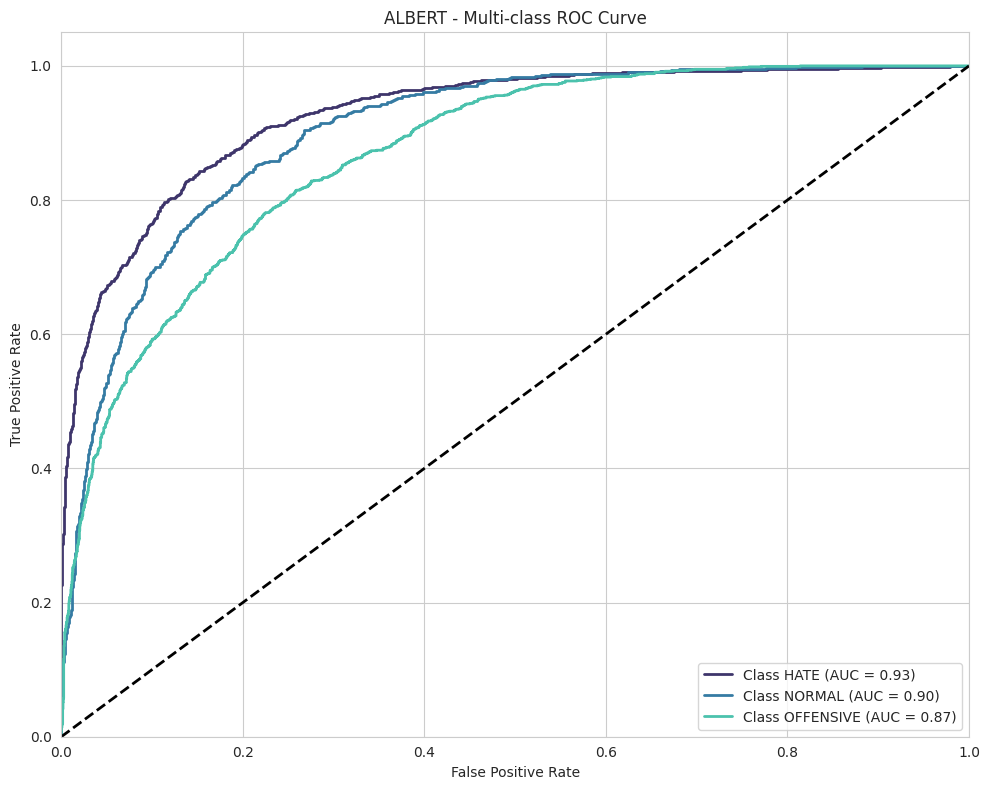

In [ ]:
best_albert.eval()
test_predictions_albert, test_labels_batch_albert, test_probabilities_albert = [], [], []

with torch.no_grad():
    for batch in test_loader_albert:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        outputs = best_albert(input_ids, attention_mask = attention_mask)
        preds = torch.argmax(outputs.logits, dim = 1)

        test_predictions_albert.extend(preds.cpu().numpy())
        test_labels_batch_albert.extend(labels.cpu().numpy())
        probs = torch.softmax(outputs.logits, dim = 1)[:, 1]
        test_probabilities_albert.extend(probs.cpu().numpy())

# Metrics
test_f1 = f1_score(test_labels_batch_albert, test_predictions_albert, average = "weighted")
test_accuracy = accuracy_score(test_labels_batch_albert, test_predictions_albert)

print(f"Test F-1 Score: {test_f1:.4f}, Test Accuracy: {test_accuracy:.4f}")

evaluate_pytorch_multiclass(
    model = best_albert,
    test_loader = test_loader_albert,
    device = device,
    label_encoder = label_encoder,
    model_name = "ALBERT"
)

#### Step 4: Model Interpretation

Validation samples for ALBERT: 4026
Baseline ALBERT weighted F1 on validation: 0.7586
Candidate words for permutation importance (first 20):
['the', 'to', 'and', 'user', 'you', 'of', 'is', 'in', 'are', 'that', 'not', 'it', 'for', 'white', 'they', 'number', 'be', 'have', 'with', 'do']
ALBERT mask token: [MASK]
Word 'the': masked F1=0.7586, ΔF1=0.0000
Word 'to': masked F1=0.7572, ΔF1=0.0014
Word 'and': masked F1=0.7587, ΔF1=-0.0001
Word 'user': masked F1=0.7561, ΔF1=0.0025
Word 'you': masked F1=0.7569, ΔF1=0.0017
Word 'of': masked F1=0.7592, ΔF1=-0.0006
Word 'is': masked F1=0.7580, ΔF1=0.0006
Word 'in': masked F1=0.7574, ΔF1=0.0012
Word 'are': masked F1=0.7584, ΔF1=0.0002
Word 'that': masked F1=0.7604, ΔF1=-0.0018
Word 'not': masked F1=0.7589, ΔF1=-0.0003
Word 'it': masked F1=0.7592, ΔF1=-0.0006
Word 'for': masked F1=0.7579, ΔF1=0.0007
Word 'white': masked F1=0.7482, ΔF1=0.0103
Word 'they': masked F1=0.7589, ΔF1=-0.0003
Word 'number': masked F1=0.7576, ΔF1=0.0010
Word 'be': masked F1=0.7

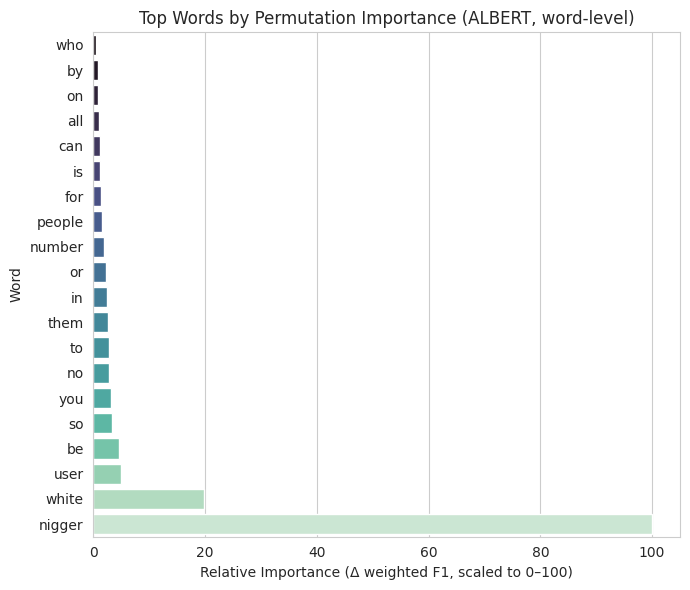

In [ ]:
# --------------------------------------------------
# 1. Use existing validation texts/labels for ALBERT
# --------------------------------------------------
# From your earlier code:
#   val_texts_albert = df_val_albert[TEXT_COLUMN].tolist()
#   val_labels_albert = df_val_albert[LABEL_COLUMN_ENCODED].tolist()

val_texts = list(val_texts_albert)
val_labels = np.array(val_labels_albert)

print(f"Validation samples for ALBERT: {len(val_texts)}")

# Max length consistent with training
MAX_LEN_ALBERT = MAX_TOKEN_LENGTH

# --------------------------------------------------
# 2. Helper: run ALBERT on a list of texts
# --------------------------------------------------

def albert_predict_from_texts(model, tokenizer, texts, device,
                              max_length = 128, batch_size = BATCH_SIZE):
    """
    Run a HuggingFace ALBERT classifier on a list of raw texts.
    Returns (pred_labels, prob_matrix).
    """
    model.eval()
    model.to(device)

    all_preds = []
    all_probs = []

    for start in range(0, len(texts), batch_size):
        batch_texts = texts[start:start + batch_size]
        enc = tokenizer(
            batch_texts,
            padding = True,
            truncation = True,
            max_length = max_length,
            return_tensors = "pt"
        )

        input_ids = enc["input_ids"].to(device)
        attention_mask = enc["attention_mask"].to(device)

        with torch.no_grad():
            outputs = model(input_ids = input_ids, attention_mask = attention_mask)
            logits = outputs.logits
            probs = torch.softmax(logits, dim = 1)
            preds = torch.argmax(probs, dim = 1)

        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

    return np.array(all_preds), np.array(all_probs)


# --------------------------------------------------
# 3. Baseline F1 on unperturbed validation texts
# --------------------------------------------------

baseline_preds, _ = albert_predict_from_texts(
    model = best_albert,
    tokenizer = tokenizer,                # <- your existing tokenizer
    texts = val_texts,
    device = device,
    max_length = MAX_LEN_ALBERT,
    batch_size = 32
)

baseline_f1_albert = f1_score(val_labels, baseline_preds, average = "weighted")
print(f"Baseline ALBERT weighted F1 on validation: {baseline_f1_albert:.4f}")

# --------------------------------------------------
# 4. Choose candidate *words* to probe
# --------------------------------------------------

# Build word frequencies from the same cleaned text representation
word_counter = Counter()
for txt in val_texts:
    if isinstance(txt, str):
        word_counter.update(txt.split())

def keep_word(w):
    # ignore empty strings and 1-char tokens (you can tighten this rule)
    return len(w) > 1

filtered_items = [(w, c) for w, c in word_counter.items() if keep_word(w)]
filtered_counter = Counter(dict(filtered_items))

TOP_WORDS = 50   # how many words to probe for importance
candidate_words = [w for (w, _) in filtered_counter.most_common(TOP_WORDS)]

print("Candidate words for permutation importance (first 20):")
print(candidate_words[:20])

mask_token = tokenizer.mask_token  # usually "[MASK]"
print("ALBERT mask token:", mask_token)

# --------------------------------------------------
# 5. Word-level permutation importance
# --------------------------------------------------

def mask_word_in_text(text, word, replacement):
    """Replace exact whitespace-delimited word with replacement."""
    if not isinstance(text, str):
        return text
    toks = text.split()
    toks = [replacement if t == word else t for t in toks]
    return " ".join(toks)

word_importances = []

for w in candidate_words:
    # skip if this word somehow never appears (defensive)
    if w not in filtered_counter:
        continue

    # produce perturbed texts with this word masked
    masked_texts = [mask_word_in_text(t, w, mask_token) for t in val_texts]

    masked_preds, _ = albert_predict_from_texts(
        model = best_albert,
        tokenizer = tokenizer,
        texts = masked_texts,
        device = device,
        max_length = MAX_LEN_ALBERT,
        batch_size = BATCH_SIZE
    )

    masked_f1 = f1_score(val_labels, masked_preds, average = "weighted")
    f1_drop = baseline_f1_albert - masked_f1

    word_importances.append({
        "Word": w,
        "Baseline_F1": baseline_f1_albert,
        "Masked_F1": masked_f1,
        "F1_Drop": f1_drop
    })

    print(f"Word '{w}': masked F1={masked_f1:.4f}, ΔF1={f1_drop:.4f}")

word_importances_df = pd.DataFrame(word_importances)
word_importances_df = word_importances_df.sort_values("F1_Drop", ascending = False)

print("\nTop 20 ALBERT word importances:")
print(word_importances_df.head(20))

# --------------------------------------------------
# 6. Scale and plot, saving to DRIVE_PROJECT_PATH
# --------------------------------------------------

max_drop = word_importances_df["F1_Drop"].max() or 1.0
word_importances_df["Scaled_Importance"] = (
    word_importances_df["F1_Drop"] / max_drop
) * 100.0

TOP_K_PLOT = 20
top_words_df = word_importances_df.head(TOP_K_PLOT).copy()
top_words_df = top_words_df.sort_values("Scaled_Importance", ascending = True)

plt.figure(figsize = (7, 6))
sns.set_style("whitegrid")
sns.barplot(
    x = "Scaled_Importance",
    y = "Word",
    data = top_words_df,
    orient = "h",
    palette = "mako"
)
plt.xlabel("Relative Importance (Δ weighted F1, scaled to 0–100)")
plt.ylabel("Word")
plt.title("Top Words by Permutation Importance (ALBERT, word-level)")
plt.tight_layout()

albert_imp_fig_path = os.path.join(DRIVE_PROJECT_PATH, "albert_token_importance_top20.png")
plt.savefig(albert_imp_fig_path, dpi = 300)
plt.show()

### 4.4 Save Predictions for DL models

In [ ]:
df_test_gru = df_gru[df_gru["split"] == "test"].copy()

# Sanity checks
assert len(df_test_gru) == len(test_labels_gru) == len(test_predictions_gru) == len(test_predictions_cnn) == len(test_predictions_albert)

y_true_gru = np.array(test_labels_gru)
gru_preds = np.array(test_predictions_gru)
gru_probs = np.array(test_probabilities_gru)

y_true_cnn = np.array(test_labels_true_cnn)
cnn_preds = np.array(test_predictions_cnn)
cnn_probs = np.array(test_probabilities_cnn)

y_true_albert = np.array(test_labels_batch_albert)
albert_preds = np.array(test_predictions_albert)
albert_prob_class1 = np.array(test_probabilities_albert)

# All true labels must match
assert np.array_equal(y_true_gru, y_true_cnn)
assert np.array_equal(y_true_gru, y_true_albert)
y_true = y_true_gru

true_label_names = label_encoder.inverse_transform(y_true)
gru_label_names = label_encoder.inverse_transform(gru_preds)
cnn_label_names = label_encoder.inverse_transform(cnn_preds)
albert_label_names = label_encoder.inverse_transform(albert_preds)

# ---------- KEY PART: construct id for DL in the same way ----------
if "id" in df_test_gru.columns:
    df_pred_dl = df_test_gru[["id", TEXT_COLUMN, LABEL_COLUMN_ENCODED]].copy()
else:
    df_pred_dl = df_test_gru[[TEXT_COLUMN, LABEL_COLUMN_ENCODED]].copy()
    df_pred_dl.insert(0, "id", df_test_gru.index)

df_pred_dl = df_pred_dl.rename(columns={
    TEXT_COLUMN: "text",
    LABEL_COLUMN_ENCODED: "true_label_id"
})

df_pred_dl["true_label"] = true_label_names

df_pred_dl["gru_pred_id"] = gru_preds
df_pred_dl["gru_pred"] = gru_label_names

df_pred_dl["cnn_pred_id"] = cnn_preds
df_pred_dl["cnn_pred"] = cnn_label_names

df_pred_dl["albert_pred_id"] = albert_preds
df_pred_dl["albert_pred"] = albert_label_names

# GRU probs
num_classes = gru_probs.shape[1]
assert num_classes == len(label_encoder.classes_)

for i, class_name in enumerate(label_encoder.classes_):
    df_pred_dl[f"gru_prob_{class_name}"] = gru_probs[:, i]

# CNN probs
num_classes_cnn = cnn_probs.shape[1]
assert num_classes_cnn == len(label_encoder.classes_)

for i, class_name in enumerate(label_encoder.classes_):
    df_pred_dl[f"cnn_prob_{class_name}"] = cnn_probs[:, i]

# ALBERT (single class prob for now)
df_pred_dl["albert_prob_class1"] = albert_prob_class1

df_pred_dl["split"] = "test"

save_path = os.path.join(DRIVE_PROJECT_PATH, "dl_models_predictions.csv")
df_pred_dl.to_csv(save_path, index=False)
print(f"Saved DL predictions to: {save_path}")

Saved DL predictions to: /content/drive/MyDrive/NLP_Projects/HateSpeech/4o_mini/dl_models_predictions.csv


# 5. Model Comparison

In [ ]:
# ====================================================
# 1. Read ML & DL prediction files
# ====================================================

ml_path = os.path.join(DRIVE_PROJECT_PATH, "ml_models_predictions.csv")
dl_path = os.path.join(DRIVE_PROJECT_PATH, "dl_models_predictions.csv")

df_ml = pd.read_csv(ml_path)
df_dl = pd.read_csv(dl_path)

print("ML columns:", df_ml.columns.tolist())
print("DL columns:", df_dl.columns.tolist())

# Sanity: both must have an 'id' and consistent truth columns
assert "id" in df_ml.columns and "id" in df_dl.columns, "Both files must have an 'id' column."
assert "true_label_id" in df_ml.columns and "true_label_id" in df_dl.columns, \
    "Both files must have 'true_label_id' column."
assert "true_label" in df_ml.columns and "true_label" in df_dl.columns, \
    "Both files must have 'true_label' column."

# ====================================================
# 2. Merge so rows are aligned across ML & DL
# ====================================================

df = pd.merge(
    df_ml,
    df_dl,
    on = ["id", "true_label", "true_label_id"],
    suffixes = ("_ml", "_dl")
)

print("Merged shape:", df.shape)
print("Merged columns:", df.columns.tolist())

# At this point we *already* enforce that true_label / true_label_id match
# across ML and DL via the merge keys, so no need for extra *_ml / *_dl checks.

# ====================================================
# 3. Build y_true and model predictions in *integer* space
# ====================================================

# Use the common true_label_id as ground truth
y_true = df["true_label_id"].values    # <--- UPDATED

# --- ML models: they are stored as strings, need to encode with label_encoder ---
lr_pred_str = df["lr_pred"].values
svm_pred_str = df["svm_pred"].values
rf_pred_str = df["rf_pred"].values
lgbm_pred_str = df["lgbm_pred"].values

# Map strings -> integer class ids using the same label_encoder
lr_pred = label_encoder.transform(lr_pred_str)
svm_pred = label_encoder.transform(svm_pred_str)
rf_pred = label_encoder.transform(rf_pred_str)
lgbm_pred = label_encoder.transform(lgbm_pred_str)

# --- DL models: already have *_pred_id in the DL file ---
gru_pred = df["gru_pred_id"].values
albert_pred = df["albert_pred_id"].values
cnn_pred = df["cnn_pred_id"].values

# Final sanity checks on lengths
n = len(y_true)
for name, arr in [
    ("LR", lr_pred),
    ("SVM", svm_pred),
    ("RF", rf_pred),
    ("LGBM", lgbm_pred),
    ("ALBERT", albert_pred),
    ("GRU", gru_pred),
    ("CNN", cnn_pred),
]:
    assert len(arr) == n, f"Length mismatch for {name}: got {len(arr)}, expected {n}"


# ====================================================
# 4. McNemar pairwise function
# ====================================================

def mcnemar_pairwise(y_true, model_preds, method="bonferroni"):
    y_true = np.asarray(y_true)
    model_names = list(model_preds.keys())
    results = []

    for m1, m2 in combinations(model_names, 2):
        y1 = np.asarray(model_preds[m1])
        y2 = np.asarray(model_preds[m2])

        assert len(y1) == len(y_true) == len(y2), f"Length mismatch for {m1} vs {m2}"

        m1_correct = (y1 == y_true)
        m2_correct = (y2 == y_true)

        a = np.sum(m1_correct & m2_correct)
        b = np.sum(m1_correct & ~m2_correct)
        c = np.sum(~m1_correct & m2_correct)
        d = np.sum(~m1_correct & ~m2_correct)

        table = np.array([[a, b],
                          [c, d]])

        res = mcnemar(table, exact = False, correction = True)
        p = res.pvalue

        if p >= 0.05:
            winner = "Inconclusive"
        elif b > c:
            winner = f"{m1} > {m2}"
        elif c > b:
            winner = f"{m2} > {m1}"
        else:
            winner = "Tie discordant"

        results.append({
            "Model 1": m1,
            "Model 2": m2,
            "a_both_correct": a,
            "b_m1_only_correct": b,
            "c_m2_only_correct": c,
            "d_both_wrong": d,
            "Statistic": res.statistic,
            "Raw p-value": p,
            "Winner (uncorrected)": winner
        })

    raw_pvals = [r["Raw p-value"] for r in results]
    _, corrected_pvals, _, _ = multipletests(raw_pvals, method=method)

    for i, p_corr in enumerate(corrected_pvals):
        results[i]["Corrected p-value"] = p_corr
        results[i]["Significant"] = "Yes" if p_corr < 0.05 else "No"

    df_res = pd.DataFrame(results)
    print(f"\nPairwise McNemar Tests (corrected with '{method}'):\n")
    print(df_res[[
        "Model 1", "Model 2",
        "a_both_correct", "b_m1_only_correct", "c_m2_only_correct", "d_both_wrong",
        "Statistic", "Raw p-value", "Corrected p-value", "Significant",
        "Winner (uncorrected)"
    ]])

    return df_res


# ====================================================
# 5. Build model_preds dict and run comparison
# ====================================================

model_preds = {
    "LR": lr_pred,
    "SVM": svm_pred,
    "RandomForest": rf_pred,
    "LGBM": lgbm_pred,
    "ALBERT": albert_pred,
    "GRU": gru_pred,
    "CNN": cnn_pred,
}

df_mcnemar = mcnemar_pairwise(
    y_true = y_true,
    model_preds = model_preds,
    method = "bonferroni"
)

ML columns: ['id', 'text_orig', 'text_ml', 'true_label', 'true_label_id', 'lr_pred', 'svm_pred', 'rf_pred', 'lgbm_pred', 'lr_prob_HATE', 'svm_prob_HATE', 'rf_prob_HATE', 'lgbm_prob_HATE', 'lr_prob_NORMAL', 'svm_prob_NORMAL', 'rf_prob_NORMAL', 'lgbm_prob_NORMAL', 'lr_prob_OFFENSIVE', 'svm_prob_OFFENSIVE', 'rf_prob_OFFENSIVE', 'lgbm_prob_OFFENSIVE', 'split']
DL columns: ['id', 'text', 'true_label_id', 'true_label', 'gru_pred_id', 'gru_pred', 'cnn_pred_id', 'cnn_pred', 'albert_pred_id', 'albert_pred', 'gru_prob_HATE', 'gru_prob_NORMAL', 'gru_prob_OFFENSIVE', 'cnn_prob_HATE', 'cnn_prob_NORMAL', 'cnn_prob_OFFENSIVE', 'albert_prob_class1', 'split']
Merged shape: (4026, 37)
Merged columns: ['id', 'text_orig', 'text_ml', 'true_label', 'true_label_id', 'lr_pred', 'svm_pred', 'rf_pred', 'lgbm_pred', 'lr_prob_HATE', 'svm_prob_HATE', 'rf_prob_HATE', 'lgbm_prob_HATE', 'lr_prob_NORMAL', 'svm_prob_NORMAL', 'rf_prob_NORMAL', 'lgbm_prob_NORMAL', 'lr_prob_OFFENSIVE', 'svm_prob_OFFENSIVE', 'rf_prob_OFFEN